# Unidad I · Fundamento de imágenes digitales
## Siete ejemplos prácticos en Python
**Visión por Computadora · Maestría en Ciencia de Datos e IA · UPN**
Prof. Luis Torrejón

Los ejemplos siguen los temas de las diapositivas desde **Representación digital
de imágenes**, página 9 del PDF. Las funciones de las bibliotecas se utilizan
para implementar esos temas, sin desarrollar métodos adicionales.

| Ejemplo | Páginas PDF | Contenido |
|---|---|---|
| 1 | 9-23 | Matriz, píxeles, muestreo, cuantización, resolución, memoria, gris, RGB/RGBA, HSV/HSL y YCbCr |
| 2 | 25-34 | Escala, proporción, interpolación, rotación, ROI, kernels, suavizado, Sobel y Prewitt |
| 3 | 36-46 | Dominio espacial y frecuencial, Fourier, magnitud, filtrado, wavelets y high-boost |
| 4 | 48-56 | Histogramas, exposición, brillo, contraste, ecualización global y CLAHE |
| 5 | 58-66 | Homogeneización, EXIF, normalización, Z-score, aumento y prevención de fugas |
| 6 | 68-77 | Recolección, anotación, oclusiones, metadatos, almacenamiento, particiones y balanceo |
| 7 | 79-87 | Integridad, etiquetas, desbalance, confusión, representatividad, Grad-CAM, privacidad y checklist |

Ejecutar de arriba abajo: el ejemplo 7 audita el dataset del ejemplo 6.
Cada ejecución crea una carpeta de resultados nueva. Algunas imágenes de
`skimage.data` pueden descargarse la primera vez. La extensión TFRecords
requiere TensorFlow y se omite si no está instalado.

In [1]:
!pip install opencv-contrib-python==4.10.0.84 scikit-image PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 9.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-contrib-python
    Found existing installation: opencv-contrib-python 4.14.0.94
    Uninstalling opencv-contrib-python-4.14.0.94:
      Successfully uninstalled opencv-contrib-python-4.14.0.94


In [ ]:
# 1. Crear y activar el entorno
# conda create -n upnvc python=3.11.15 -y
# conda activate upnvc

#Con CUDA
# 2. Instalar PyTorch con soporte CUDA 11.8
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

#Sin CUDA
# 2. Instalar PyTorch exclusivo para CPU
#pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

# 3. Instalar librerías fijando la versión estable de OpenCV
# pip install opencv-contrib-python==4.10.0.84 numpy pandas scikit-learn matplotlib scikit-image scipy pillow PyWavelets nbformat nbclient ipykernel

In [2]:
# Instalar una vez si faltan dependencias, desde el kernel correcto:
# %pip install numpy pandas matplotlib opencv-python pillow scikit-image scipy scikit-learn PyWavelets torch torchvision
import importlib.util
requeridos = {'cv2': 'opencv-python', 'pywt': 'PyWavelets', 'torch': 'torch',
              'torchvision': 'torchvision', 'skimage': 'scikit-image'}
faltantes = [paquete for modulo, paquete in requeridos.items()
             if importlib.util.find_spec(modulo) is None]
if faltantes:
    raise ImportError('Instala en este kernel con %pip install ' + ' '.join(faltantes))

import os, time, json, shutil, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from IPython.display import display
import tempfile
SALIDAS = Path(tempfile.mkdtemp(prefix="unidad_I_", dir=".")).resolve().relative_to(Path.cwd().resolve())
print("Carpeta de resultados:", SALIDAS.resolve())
from skimage import data

np.random.seed(42)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 140)

def mostrar(imgs, titulos=None, cols=None, tam=3.2, cmap="gray", vmin=None, vmax=None):
    """Muestra una lista de imágenes en cuadrícula. Las uint8 en gris se muestran en [0, 255] sin reescalar."""
    n = len(imgs)
    if n == 0:
        print("No hay imágenes para mostrar.")
        return
    cols = cols or n; filas = int(np.ceil(n / cols))
    fig, axes = plt.subplots(filas, cols, figsize=(tam * cols, tam * filas))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes: ax.axis("off")
    for i, img in enumerate(imgs):
        if img.ndim == 2:
            lo, hi = vmin, vmax
            if img.dtype == np.uint8:
                if lo is None: lo = 0
                if hi is None: hi = 255
            axes[i].imshow(img, cmap=cmap, vmin=lo, vmax=hi)
        else:
            axes[i].imshow(img)
        if titulos: axes[i].set_title(titulos[i], fontsize=9)
    plt.tight_layout(); plt.show()

# Imágenes de trabajo (skimage.data puede descargar las que no estén en caché)
astronauta = data.astronaut()   # RGB 512×512
camara     = data.camera()      # gris 512×512
cafe       = data.coffee()      # RGB 400×600
gato       = data.chelsea()     # RGB 300×451
luna       = data.moon()        # gris de bajo contraste
print("Entorno listo · OpenCV", cv2.__version__)

Carpeta de resultados: /content/unidad_I_5b9nsmn7
Entorno listo · OpenCV 4.10.0


---
# Ejemplo 1 · Representación digital de imágenes (píxeles, resolución, color)

**Objetivo.** Comprobar con código que una imagen es una matriz de números, cuantificar cuánto cuesta en memoria, y observar el efecto del muestreo y la cuantización. Se comparan los modelos de color presentados en las diapositivas.

### 1.1 La imagen es una matriz `f(x, y)`
Ojo con la convención: NumPy indexa `img[fila, columna]`, es decir `img[y, x]`.


Compara **cámara, astronauta y café**: la tabla muestra las matrices originales y cada fila de la figura muestra la imagen completa y un recorte de 8×8 en la misma posición. En las imágenes RGB, solo el recorte se convierte a gris para representar una intensidad por píxel. Todos los recortes usan la escala fija de 0 a 255.


,Imagen,Forma,Tipo,Canales,Mínimo,Máximo,"Píxel [100, 200]"
0,Cámara,"(512, 512)",uint8,1,0,255,54
1,Astronauta,"(512, 512, 3)",uint8,3,0,255,[81 57 17]
2,Café,"(400, 600, 3)",uint8,3,0,255,[203 143 85]


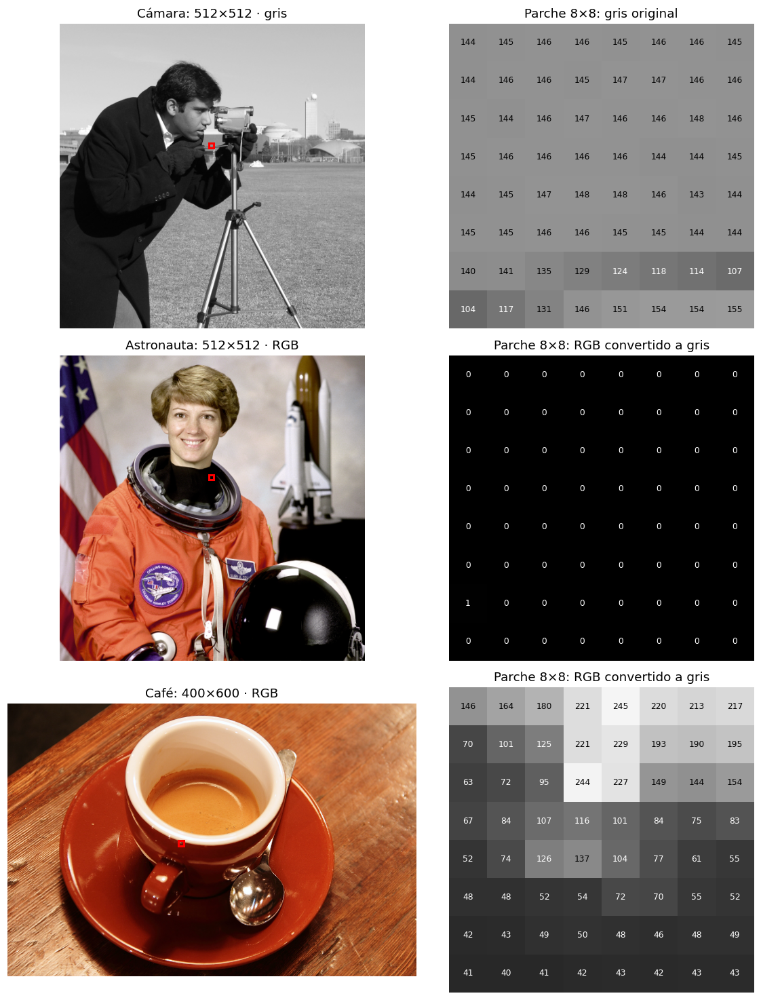

In [3]:
# Tres imágenes para comparar su representación como matrices.
imagenes_11 = [("Cámara", camara), ("Astronauta", astronauta), ("Café", cafe)]
display(pd.DataFrame([
    {"Imagen": nombre, "Forma": str(img.shape), "Tipo": str(img.dtype),
     "Canales": 1 if img.ndim == 2 else img.shape[2],
     "Mínimo": int(img.min()), "Máximo": int(img.max()),
     "Píxel [100, 200]": str(img[100, 200])}
    for nombre, img in imagenes_11
]))

y0, x0 = 200, 250
fig, axes = plt.subplots(3, 2, figsize=(11, 13.5))
for fila, (nombre, img) in enumerate(imagenes_11):
    # RGB se convierte a gris solo para anotar una intensidad por píxel.
    gris = img if img.ndim == 2 else cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    parche_11 = gris[y0:y0 + 8, x0:x0 + 8]
    ax_img, ax_parche = axes[fila]
    ax_img.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax_img.add_patch(plt.Rectangle((x0, y0), 8, 8,
                                  edgecolor="red", fill=False, lw=2))
    modo = "gris" if img.ndim == 2 else "RGB"
    ax_img.set_title(f"{nombre}: {img.shape[0]}×{img.shape[1]} · {modo}")
    ax_parche.imshow(parche_11, cmap="gray", vmin=0, vmax=255,
                     interpolation="nearest")
    for i in range(8):
        for j in range(8):
            v = int(parche_11[i, j])
            ax_parche.text(j, i, v, ha="center", va="center", fontsize=8,
                           color="white" if v < 128 else "black")
    origen = "gris original" if img.ndim == 2 else "RGB convertido a gris"
    ax_parche.set_title(f"Parche 8×8: {origen}")
    ax_img.axis("off")
    ax_parche.axis("off")

# Conservar las variables del ejemplo original para las siguientes secciones.
parche = camara[y0:y0 + 8, x0:x0 + 8]
plt.tight_layout(); plt.show()


### 1.2 Resolución y costo computacional
La memoria de la matriz depende del alto, ancho, cantidad de canales y bytes
por valor. Duplicar ambos lados cuadruplica la cantidad de píxeles.

In [4]:
def memoria_bytes(h, w, canales, bytes_por_valor):
    return h * w * canales * bytes_por_valor

resoluciones = {"224×224 (clasificación)": (224, 224), "640×640 (detección)": (640, 640),
                "1920×1080 (Full HD)": (1080, 1920), "3840×2160 (4K)": (2160, 3840)}
filas = []
for nombre, (h, w) in resoluciones.items():
    filas.append({"Resolución": nombre,
                  "Megapíxeles": h * w / 1e6,
                  "uint8 RGB (MiB)": memoria_bytes(h, w, 3, 1) / 2**20,
                  "float32 RGB (MiB)": memoria_bytes(h, w, 3, 4) / 2**20,
                  "Lote de 32 en float32 (GiB)": 32 * memoria_bytes(h, w, 3, 4) / 2**30})
pd.DataFrame(filas).round(2)

,Resolución,Megapíxeles,uint8 RGB (MiB),float32 RGB (MiB),Lote de 32 en float32 (GiB)
0,224×224 (clasificación),0.05,0.14,0.57,0.02
1,640×640 (detección),0.41,1.17,4.69,0.15
2,1920×1080 (Full HD),2.07,5.93,23.73,0.74
3,3840×2160 (4K),8.29,23.73,94.92,2.97


### 1.3 Muestreo espacial
El muestreo determina cuántas posiciones de la imagen se representan.
Comparamos una misma fotografía con distintas cantidades de filas y columnas.
Al reducir la resolución se pierde detalle; ampliarla no recupera la información eliminada.

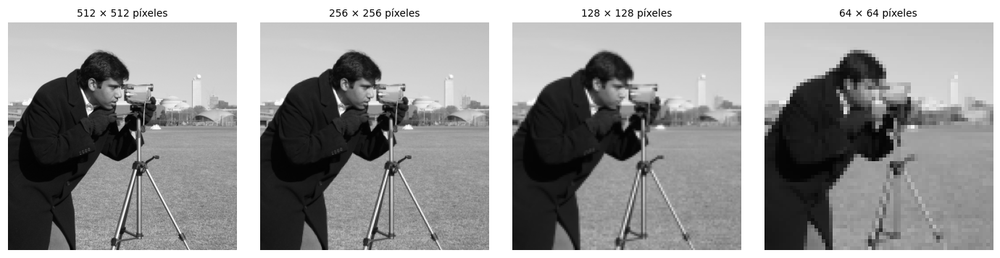

,Resolución,Cantidad de píxeles,Memoria (bytes)
0,"(512, 512)",262144,262144
1,"(256, 256)",65536,65536
2,"(128, 128)",16384,16384
3,"(64, 64)",4096,4096


In [5]:
resoluciones13=[512,256,128,64]
muestreadas13=[cv2.resize(camara,(lado,lado),interpolation=cv2.INTER_AREA) for lado in resoluciones13]
mostrar(muestreadas13,[f"{lado} × {lado} píxeles" for lado in resoluciones13])
display(pd.DataFrame({'Resolución':[im.shape for im in muestreadas13],
                      'Cantidad de píxeles':[im.size for im in muestreadas13],
                      'Memoria (bytes)':[im.nbytes for im in muestreadas13]}))

### 1.4 Cuantización: profundidad de bits
La profundidad de bits determina cuántos niveles de intensidad se pueden
representar: con b bits hay hasta 2 elevado a b niveles. Comparamos la misma
imagen con diferentes cantidades de niveles.

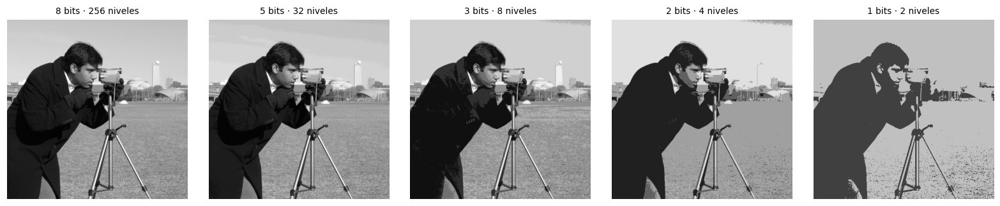

In [6]:
def cuantizar(img, bits):
    if img.dtype != np.uint8 or not isinstance(bits, (int, np.integer)) or not 1 <= bits <= 8:
        raise ValueError("Se requiere uint8 y bits enteros entre 1 y 8")
    paso = 256 // (2 ** bits)
    return ((img // paso) * paso + paso // 2).astype(np.uint8)

bits_lista = [8, 5, 3, 2, 1]
versiones = [cuantizar(camara, b) for b in bits_lista]
mostrar(versiones, [f"{b} bits · {len(np.unique(v))} niveles" for b,v in zip(bits_lista,versiones)], tam=2.9)

### 1.5 Escala de grises: ponderada, no promedio
El ojo es mucho más sensible al verde que al azul. Un promedio simple asigna el mismo gris a un verde y a un azul puros; la ponderación ITU-R BT.601 (la que usa OpenCV) no.

Diferencia máx. BT.601 manual vs OpenCV: 1.0 nivel(es)
            Promedio  BT.601
Rojo puro       85.0    76.2
Verde puro      85.0   149.7
Azul puro       85.0    29.1


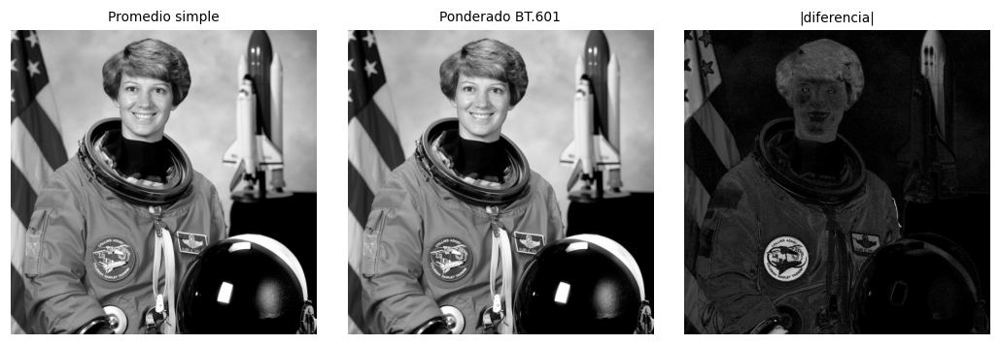

In [7]:
rgb = astronauta.astype(np.float32)
gris_promedio = rgb.mean(axis=2)
gris_bt601    = 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
gris_opencv   = cv2.cvtColor(astronauta, cv2.COLOR_RGB2GRAY)

print("Diferencia máx. BT.601 manual vs OpenCV:", np.abs(np.round(gris_bt601) - gris_opencv).max(), "nivel(es)")
colores = {"Rojo puro": (255, 0, 0), "Verde puro": (0, 255, 0), "Azul puro": (0, 0, 255)}
print(pd.DataFrame({n: {"Promedio": np.mean(c), "BT.601": 0.299*c[0] + 0.587*c[1] + 0.114*c[2]}
                    for n, c in colores.items()}).T.round(1))

mostrar([gris_promedio, gris_bt601, np.abs(gris_promedio - gris_bt601)],
        ["Promedio simple", "Ponderado BT.601", "|diferencia|"], cmap="gray")

### 1.6 ¿Por qué HSV? Segmentar color con iluminación no uniforme
Construimos una escena con tres discos y le aplicamos un degradado de iluminación. Un umbral en RGB mezcla color y luz; en HSV el tono (H) y la saturación (S) no cambian cuando toda la escena se oscurece por igual, solo cambia V.

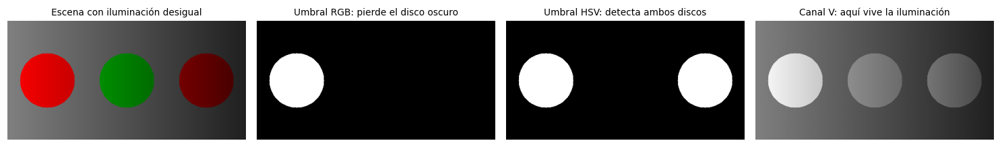

In [8]:
escena = np.full((240, 480, 3), 128, np.uint8)
for (cx, color) in [(80, (255, 0, 0)), (240, (0, 200, 0)), (400, (255, 0, 0))]:
    cv2.circle(escena, (cx, 120), 55, color, -1)
degradado = np.linspace(1.0, 0.25, escena.shape[1])[None, :, None]   # luz que cae de izquierda a derecha
escena_luz = (escena * degradado).astype(np.uint8)

R, G, B = [escena_luz[..., i].astype(int) for i in range(3)]
mascara_rgb = (R > 150) & (G < 100) & (B < 100)

hsv = cv2.cvtColor(escena_luz, cv2.COLOR_RGB2HSV)          # en OpenCV H ∈ [0, 180)
H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]
mascara_hsv = ((H < 10) | (H > 170)) & (S > 100) & (V > 40)  # el rojo está en ambos extremos del círculo de tono

mostrar([escena_luz, mascara_rgb, mascara_hsv, V],
        ["Escena con iluminación desigual", "Umbral RGB: pierde el disco oscuro",
         "Umbral HSV: detecta ambos discos", "Canal V: aquí vive la iluminación"], tam=3.4)

### 1.7 YCbCr: luminancia y crominancia
Separamos Y, Cb y Cr y comparamos el efecto de reducir la resolución de la
crominancia o de la luminancia. Este principio se utiliza en compresión y video.

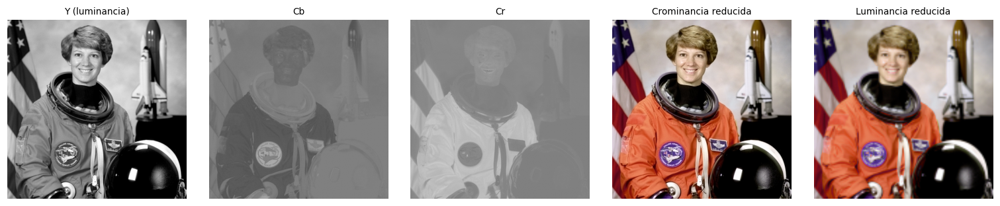

In [9]:
ycc = cv2.cvtColor(astronauta, cv2.COLOR_RGB2YCrCb)    # OpenCV ordena Y, Cr, Cb

def degradar_canales(ycc, canales, f=4):
    out = ycc.copy()
    h, w = ycc.shape[:2]
    for c in canales:
        peq = cv2.resize(ycc[..., c], (w // f, h // f), interpolation=cv2.INTER_AREA)
        out[..., c] = cv2.resize(peq, (w, h), interpolation=cv2.INTER_LINEAR)
    return cv2.cvtColor(out, cv2.COLOR_YCrCb2RGB)

solo_croma = degradar_canales(ycc, [1, 2])
solo_luma  = degradar_canales(ycc, [0])
mostrar([ycc[...,0],ycc[...,2],ycc[...,1],solo_croma,solo_luma],
        ["Y (luminancia)","Cb","Cr","Crominancia reducida","Luminancia reducida"],cols=5,tam=2.8)

### 1.8 Profundidad real de 12/16 bits y canal alfa (PDF 13, 18)
Reducir a 8 bits pierde niveles aunque después se guarde en `uint16`.
RGBA añade opacidad, no un cuarto color: `salida = alfa·RGB + (1−alfa)·fondo`.


Niveles antes/después: 4096 256
12 bits en contenedor uint16: 8192 bytes (16 bits almacenados por valor)


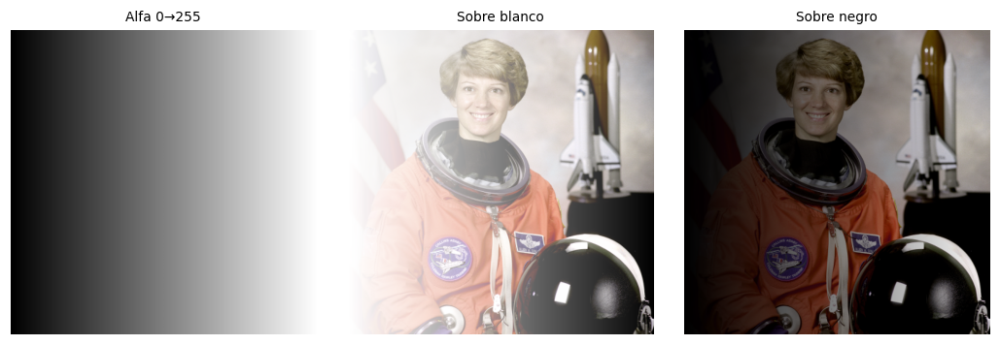

Bytes gris/RGB/RGBA: 262144 786432 1048576


In [10]:
rampa12 = np.arange(4096, dtype=np.uint16).reshape(64, 64)
rampa8 = (rampa12 // 16).astype(np.uint8)
print("Niveles antes/después:", len(np.unique(rampa12)), len(np.unique(rampa8)))
print("12 bits en contenedor uint16:", rampa12.nbytes, "bytes (16 bits almacenados por valor)")
alfa19 = np.tile(np.linspace(0, 255, astronauta.shape[1], dtype=np.uint8), (astronauta.shape[0], 1))
rgba19 = np.dstack([astronauta, alfa19])
a19 = rgba19[..., 3:4].astype(np.float32) / 255
componer19 = lambda fondo: np.round(rgba19[..., :3]*a19 + fondo*(1-a19)).astype(np.uint8)
mostrar([alfa19, componer19(255), componer19(0)], ["Alfa 0→255", "Sobre blanco", "Sobre negro"])
print("Bytes gris/RGB/RGBA:", gris_opencv.nbytes, astronauta.nbytes, rgba19.nbytes)

### 1.9 HSV frente a HSL (PDF 19-21)
OpenCV llama **HLS** al orden de canales de HSL: tono, luminosidad, saturación.
En uint8, H usa 0-179; los demás canales usan 0-255. `V=max(R,G,B)` y
`L=(max+min)/2` sobre valores normalizados. El tono de un gris no está definido
físicamente, aunque la biblioteca almacene un cero.

,RGB,HSV,"HLS (H,L,S)"
0,"(255, 0, 0)","(0, 255, 255)","(0, 128, 255)"
1,"(128, 0, 0)","(0, 255, 128)","(0, 64, 255)"
2,"(255, 128, 128)","(0, 127, 255)","(0, 192, 255)"
3,"(128, 128, 128)","(0, 0, 128)","(0, 128, 0)"


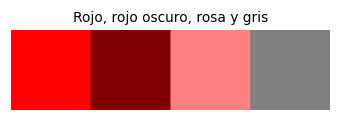

In [11]:
muestras110 = np.array([[[255,0,0], [128,0,0], [255,128,128], [128,128,128]]], dtype=np.uint8)
hsv110 = cv2.cvtColor(muestras110, cv2.COLOR_RGB2HSV)[0]
hls110 = cv2.cvtColor(muestras110, cv2.COLOR_RGB2HLS)[0]
display(pd.DataFrame({'RGB': list(map(tuple,muestras110[0])), 'HSV': list(map(tuple,hsv110)),
                      'HLS (H,L,S)': list(map(tuple,hls110))}))
mostrar([cv2.resize(muestras110,(400,100),interpolation=cv2.INTER_NEAREST)], ["Rojo, rojo oscuro, rosa y gris"])

**Para discutir en clase**
1. ¿Qué diferencia hay entre reducir la resolución y reducir la profundidad de bits?
2. ¿Por qué RGB necesita más memoria que una imagen en gris del mismo tamaño?
3. ¿Cuándo conviene utilizar HSV o YCbCr?

---
# Ejemplo 2 · Operaciones básicas de procesamiento
**Objetivo.** Aplicar escala, rotación, recorte, filtros y detección de bordes.

### 2.1 Escalado y conservación de la proporción
Comparamos un cambio de tamaño que deforma la imagen con otro que conserva
la relación entre ancho y alto. Para obtener un tamaño fijo sin deformarla,
se puede completar el espacio sobrante con un fondo uniforme.

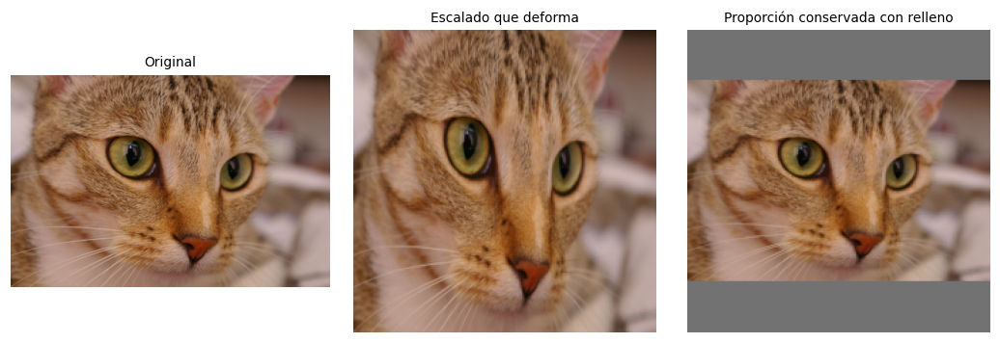

Relación ancho/alto original: 1.5


In [12]:
def redimensionar_con_aspecto(img, lado_max, interp=cv2.INTER_AREA):
    h, w = img.shape[:2]
    s = lado_max / max(h, w)
    return cv2.resize(img, (round(w * s), round(h * s)), interpolation=interp), s

def ajustar_tamano(img, tam=224, relleno=114):
    red, s = redimensionar_con_aspecto(img, tam)
    h, w = red.shape[:2]
    izq, arriba = (tam - w) // 2, (tam - h) // 2
    lienzo = np.full((tam, tam) + img.shape[2:], relleno, dtype=img.dtype)
    lienzo[arriba:arriba + h, izq:izq + w] = red
    return lienzo, s, (izq, arriba)

deformada = cv2.resize(gato, (224, 224), interpolation=cv2.INTER_AREA)
lb, s, (dx, dy) = ajustar_tamano(gato, 224)

mostrar([gato,deformada,lb],["Original","Escalado que deforma","Proporción conservada con relleno"])
print("Relación ancho/alto original:",round(gato.shape[1]/gato.shape[0],2))

### 2.2 Métodos de interpolación
Comparamos los tres métodos de las diapositivas: vecino más cercano, bilineal
y bicúbico. Observamos sus resultados al ampliar el mismo recorte.

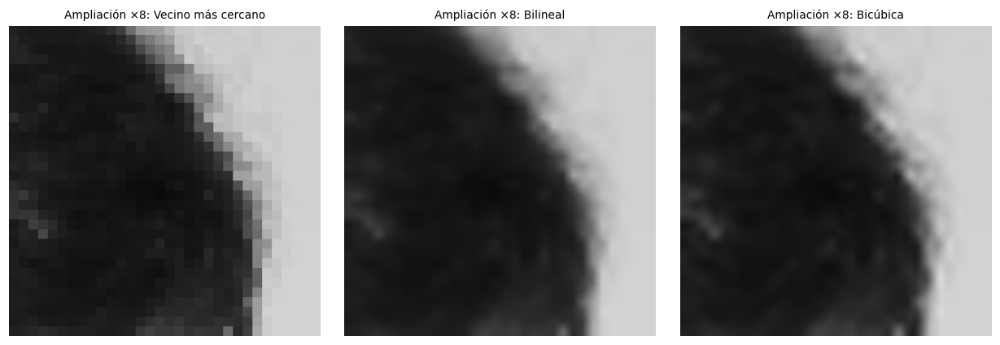

In [13]:
metodos={"Vecino más cercano":cv2.INTER_NEAREST,"Bilineal":cv2.INTER_LINEAR,"Bicúbica":cv2.INTER_CUBIC}
recorte=camara[95:127,245:277]
mostrar([cv2.resize(recorte,None,fx=8,fy=8,interpolation=m) for m in metodos.values()],
        [f"Ampliación ×8: {nombre}" for nombre in metodos],tam=3.8)

### 2.3 Rotación y ampliación del lienzo
Giramos una imagen 30 grados. Comparamos conservar el tamaño original con
ampliar el lienzo para evitar el recorte de las esquinas.

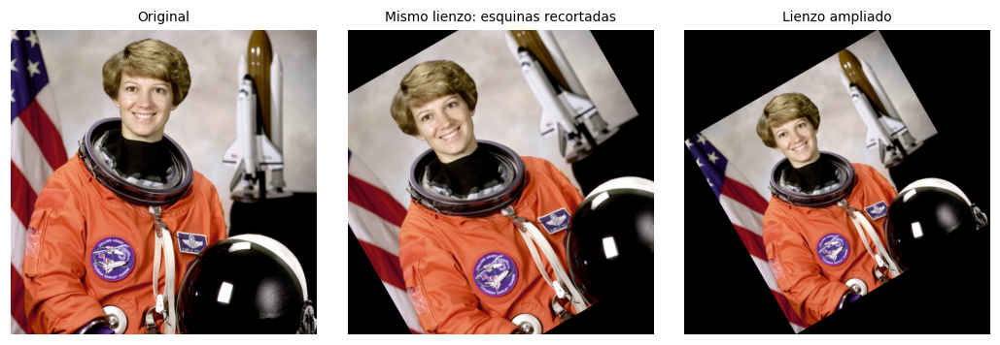

In [14]:
def rotar_sin_recortar(img,angulo):
    h,w=img.shape[:2]
    M=cv2.getRotationMatrix2D((w/2,h/2),angulo,1)
    co,si=abs(M[0,0]),abs(M[0,1])
    nw,nh=int(np.ceil(h*si+w*co)),int(np.ceil(h*co+w*si))
    M[0,2]+=nw/2-w/2;M[1,2]+=nh/2-h/2
    return cv2.warpAffine(img,M,(nw,nh))
h,w=astronauta.shape[:2]
matriz29=cv2.getRotationMatrix2D((w/2,h/2),30,1)
rot_constante=cv2.warpAffine(astronauta,matriz29,(w,h))
rot_completa=rotar_sin_recortar(astronauta,30)
mostrar([astronauta,rot_constante,rot_completa],["Original","Mismo lienzo: esquinas recortadas","Lienzo ampliado"])

### 2.4 Recorte de una región de interés (ROI)
Seleccionamos una región mediante sus coordenadas para concentrar el análisis
en el objeto y reducir la cantidad de píxeles procesados.

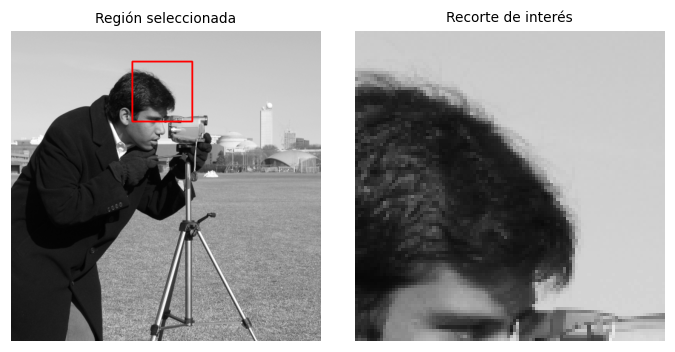

Píxeles antes/después: 262144 10000


In [15]:
y1_roi,y2_roi,x1_roi,x2_roi=50,150,200,300
roi_segura=camara[y1_roi:y2_roi,x1_roi:x2_roi].copy()
vista_roi=cv2.cvtColor(camara,cv2.COLOR_GRAY2RGB)
cv2.rectangle(vista_roi,(x1_roi,y1_roi),(x2_roi-1,y2_roi-1),(255,0,0),2)
mostrar([vista_roi,roi_segura],["Región seleccionada","Recorte de interés"])
print("Píxeles antes/después:",camara.size,roi_segura.size)

### 2.5 Filtros de suavizado
Comparamos promedio, gaussiano y mediana sobre imágenes con ruido.
Observamos la reducción del ruido y la pérdida de detalle.

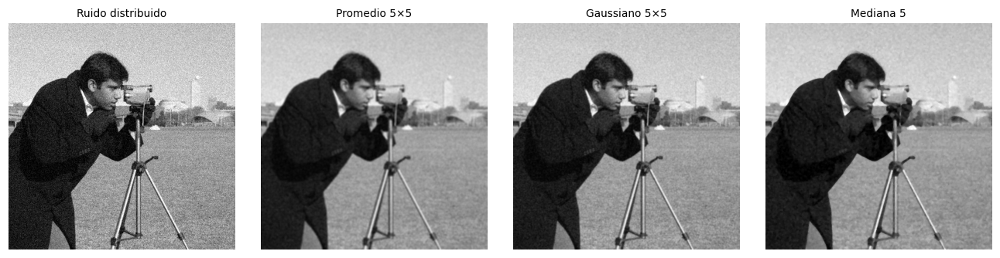

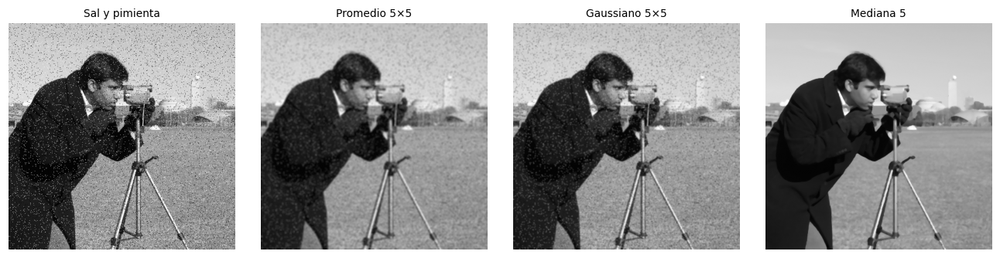

In [16]:
rng = np.random.default_rng(0)
ruido_gauss = np.clip(camara + rng.normal(0, 20, camara.shape), 0, 255).astype(np.uint8)
ruido_sp = camara.copy()
m = rng.random(camara.shape)
ruido_sp[m < 0.03] = 0; ruido_sp[m > 0.97] = 255      # sal y pimienta al 6 %

filtros={"Promedio 5×5":lambda im:cv2.blur(im,(5,5)),
         "Gaussiano 5×5":lambda im:cv2.GaussianBlur(im,(5,5),0),
         "Mediana 5":lambda im:cv2.medianBlur(im,5)}
for nombre,ruidosa25 in [("Ruido distribuido",ruido_gauss),("Sal y pimienta",ruido_sp)]:
    mostrar([ruidosa25]+[fn(ruidosa25) for fn in filtros.values()],[nombre]+list(filtros),cols=4,tam=3)


### 2.6 Kernels y gradientes Sobel
Un kernel define los pesos de una operación de vecindario. Los operadores
Sobel destacan cambios de intensidad en dirección horizontal y vertical.

Kernel horizontal:
 [[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]


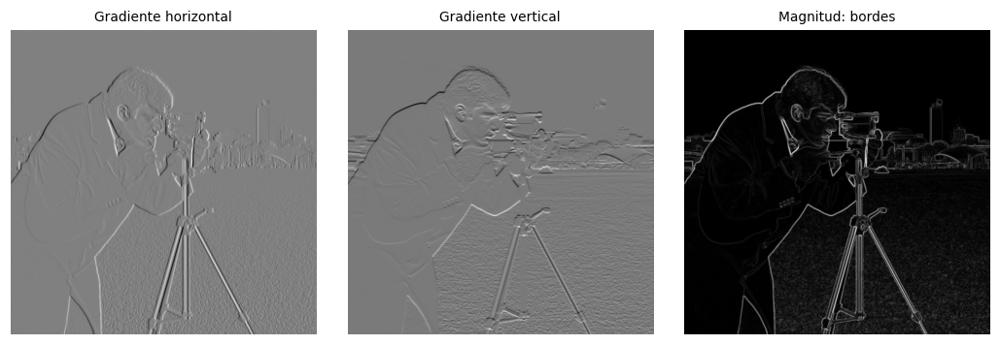

In [17]:
sobel_x=np.array([[-1,0,1],[-2,0,2],[-1,0,1]],np.float32)
sobel_y=sobel_x.T
gx=cv2.filter2D(camara.astype(np.float32),cv2.CV_32F,sobel_x)
gy=cv2.filter2D(camara.astype(np.float32),cv2.CV_32F,sobel_y)
magnitud=np.hypot(gx,gy)
print("Kernel horizontal:\n",sobel_x)
mostrar([gx,gy,magnitud],["Gradiente horizontal","Gradiente vertical","Magnitud: bordes"])

### 2.7 Prewitt frente a Sobel (PDF 33)
Ambos estiman derivadas locales; Sobel pondera más la fila central.
La misma escala de visualización permite comparar respuestas sin autoajuste.

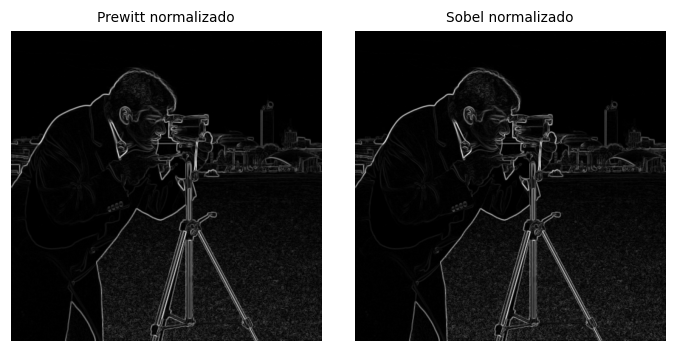

In [18]:
prewitt_x = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], np.float32)
prewitt_mag = np.hypot(cv2.filter2D(camara.astype(np.float32),cv2.CV_32F,prewitt_x/6), cv2.filter2D(camara.astype(np.float32),cv2.CV_32F,prewitt_x.T/6))
sobel_mag = np.hypot(gx/8, gy/8)
mostrar([prewitt_mag, sobel_mag], ["Prewitt normalizado", "Sobel normalizado"], vmin=0, vmax=max(prewitt_mag.max(),sobel_mag.max()))

**Para discutir en clase**
1. ¿Por qué es importante conservar la proporción al escalar?
2. ¿Qué cambia al ampliar el lienzo durante una rotación?
3. ¿Qué diferencias observas entre los filtros promedio, gaussiano y mediana?

---
# Ejemplo 3 · Transformaciones en el dominio espacial y frecuencial
**Objetivo.** Visualizar la magnitud del espectro de Fourier, reconocer bajas
y altas frecuencias, filtrar y observar una descomposición wavelet.

### 3.1 El espectro de Fourier
Los patrones periódicos producen puntos destacados en el espectro.
La escala logarítmica permite ver componentes de distintas magnitudes.

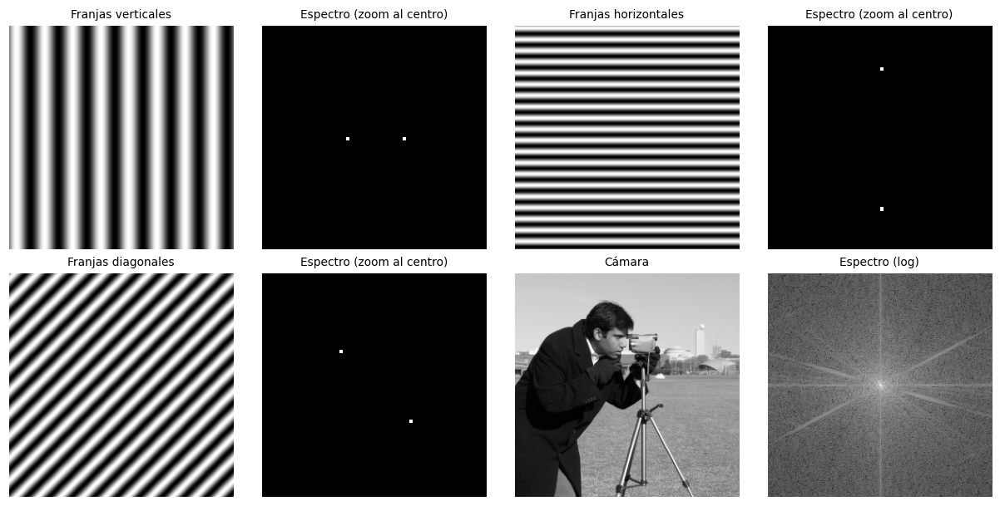

In [19]:
def espectro(img):
    F = np.fft.fftshift(np.fft.fft2(img.astype(np.float32)))
    return F, np.log1p(np.abs(F))

yy, xx = np.mgrid[0:256, 0:256]
patrones = {"Franjas verticales": np.sin(2 * np.pi * xx * 8 / 256),
            "Franjas horizontales": np.sin(2 * np.pi * yy * 20 / 256),
            "Franjas diagonales": np.sin(2 * np.pi * (xx * 10 + yy * 10) / 256),
            "Cámara": cv2.resize(camara, (256, 256), interpolation=cv2.INTER_AREA).astype(float)}
imgs, tits = [], []
for n, p in patrones.items():
    esp = espectro(p)[1]
    if n != "Cámara":                           # zoom al centro para que los picos se vean
        esp, t = esp[96:160, 96:160], "Espectro (zoom al centro)"
    else:
        t = "Espectro (log)"
    imgs += [p, esp]; tits += [n, t]
mostrar(imgs, tits, cols=4, tam=2.8)

### 3.2 Filtros gaussianos paso bajo y paso alto
El paso bajo conserva las variaciones suaves y atenúa detalles finos.
El paso alto atenúa el componente uniforme y destaca bordes.
Se multiplica el espectro por el filtro y se reconstruye la imagen.

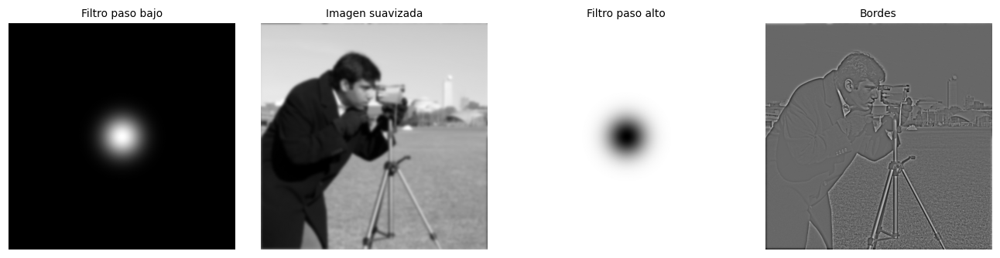

In [20]:
def distancias(forma):
    h, w = forma
    v, u = np.mgrid[-(h // 2):h - h // 2, -(w // 2):w - w // 2]
    return np.sqrt(u**2 + v**2)

def filtrar_frecuencia(img, H):
    F = np.fft.fftshift(np.fft.fft2(img.astype(np.float32)))
    return np.real(np.fft.ifft2(np.fft.ifftshift(F * H)))

D=distancias(camara.shape);D0=30
H_gauss_pb=np.exp(-(D**2)/(2*D0**2))
H_gauss_pa=1-H_gauss_pb
mostrar([H_gauss_pb,filtrar_frecuencia(camara,H_gauss_pb),H_gauss_pa,filtrar_frecuencia(camara,H_gauss_pa)],
        ["Filtro paso bajo","Imagen suavizada","Filtro paso alto","Bordes"],cols=4,tam=3)


### 3.3 Picos de interferencia en el espectro
El PDF muestra que una interferencia periódica aparece como picos destacados.
Localizamos esos picos y atenuamos sus componentes antes de reconstruir la imagen.

Picos encontrados (fila, columna) respecto al centro: [(np.int64(-12), np.int64(-20)), (np.int64(12), np.int64(20))]


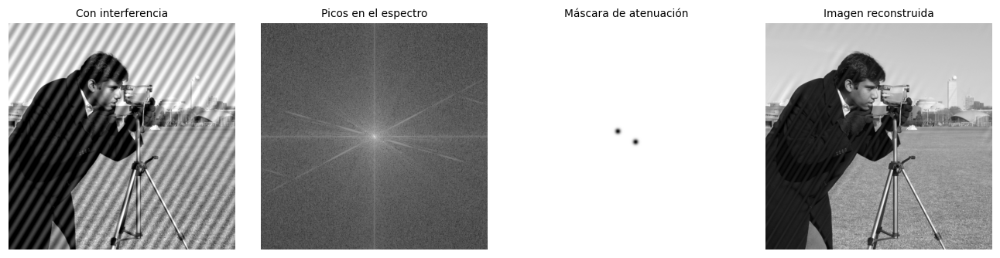

In [21]:
h, w = camara.shape
yy, xx = np.mgrid[0:h, 0:w]
interferencia = 40 * np.sin(2 * np.pi * (xx * 20 / w + yy * 12 / h))
ruidosa = np.clip(camara + interferencia, 0, 255).astype(np.uint8)

# 1) Localizar los picos automáticamente, ignorando el centro (la componente de baja frecuencia)
F, logF = espectro(ruidosa)
D = distancias(ruidosa.shape)
busqueda = np.where(D > 10, logF, 0)
picos = []
for _ in range(2):
    fy, fx = np.unravel_index(np.argmax(busqueda), busqueda.shape)
    picos.append((fy, fx))
    busqueda[max(fy-5, 0):fy+6, max(fx-5, 0):fx+6] = 0
print("Picos encontrados (fila, columna) respecto al centro:", [(py - h//2, px - w//2) for py, px in picos])

# 2) Atenuar suavemente la zona de cada pico
v, u = np.mgrid[0:h, 0:w]
H_interferencia = np.ones((h, w), np.float32)
for py, px in picos:
    H_interferencia *= 1 - np.exp(-((v - py)**2 + (u - px)**2) / (2 * 4**2))
restaurada = np.clip(filtrar_frecuencia(ruidosa, H_interferencia), 0, 255).astype(np.uint8)
suavizada = cv2.GaussianBlur(ruidosa, (9, 9), 0)

mostrar([ruidosa,logF,H_interferencia,restaurada],["Con interferencia","Picos en el espectro","Máscara de atenuación","Imagen reconstruida"],cols=4,tam=3)

### 3.4 Wavelets: frecuencia y localización
Observamos la aproximación y los detalles de la imagen en dos escalas.
Esta representación conserva información de ubicación y frecuencia,
como se presenta en el bloque de transformaciones del PDF.

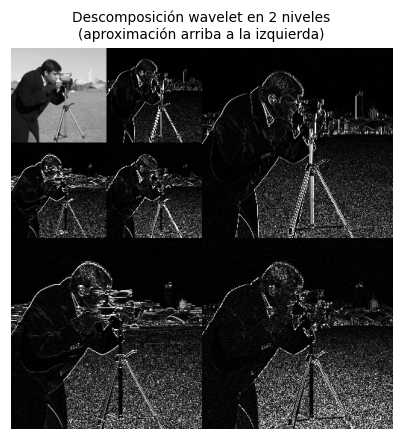

In [22]:
import pywt

coefs = pywt.wavedec2(camara.astype(np.float32), "haar", level=2)
# Para visualizar: aproximación escalada a [0, 1] y cada detalle en valor absoluto recortado a su percentil 99
vis = [coefs[0] / coefs[0].max()] + [tuple(np.clip(np.abs(d) / np.percentile(np.abs(d), 99), 0, 1) for d in nivel)
                                     for nivel in coefs[1:]]
arreglo, _ = pywt.coeffs_to_array(vis)
fig = plt.figure(figsize=(4.5, 4.5)); plt.imshow(arreglo, cmap="gray", vmin=0, vmax=1); plt.axis("off")
plt.title("Descomposición wavelet en 2 niveles\n(aproximación arriba a la izquierda)", fontsize=9); plt.show()

### 3.5 DFT separable y realce high-boost (PDF 42, 46)
La DFT 2D equivale a transformar primero filas y luego columnas. Para realzar:
`detalle=f−pasabajo(f)` y `g=f+k·detalle`. El detalle tiene signo; tomar su valor
absoluto antes de sumarlo sesga el brillo. El realce también amplifica ruido.

Píxeles fuera del rango antes del recorte: 6.25%


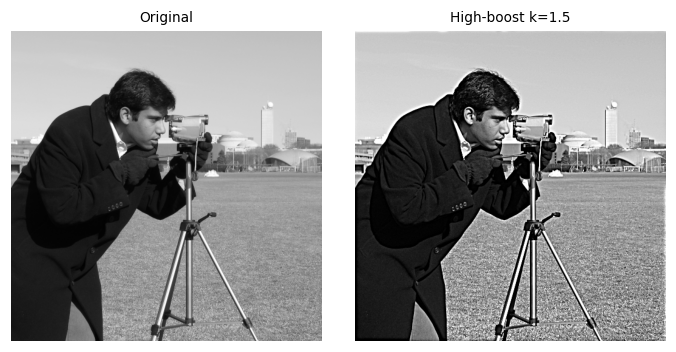

In [23]:
f37 = camara.astype(np.float64)  # doble precisión para verificar la separabilidad
fft_separable = np.fft.fft(np.fft.fft(f37, axis=0), axis=1)
assert np.allclose(fft_separable, np.fft.fft2(f37))
baja37 = filtrar_frecuencia(f37, H_gauss_pb)
detalle37 = f37 - baja37
realce37 = f37 + 1.5*detalle37
print("Píxeles fuera del rango antes del recorte:", f"{((realce37<0)|(realce37>255)).mean():.2%}")
mostrar([camara, np.clip(realce37,0,255).astype(np.uint8)], ["Original", "High-boost k=1.5"])
assert np.allclose(filtrar_frecuencia(f37, H_gauss_pa), detalle37, atol=1e-4)

**Para discutir en clase**
1. ¿Qué representan las frecuencias bajas y las altas?
2. ¿Cómo aparece una interferencia periódica en el espectro?
3. ¿Qué efecto tiene sumar el detalle de alta frecuencia a la imagen original?

---
# Ejemplo 4 · Histogramas y análisis de intensidad

**Objetivo.** Tratar el histograma como una distribución de probabilidad, construir un diagnóstico automático de exposición y comparar la ecualización global con CLAHE y observar sus efectos sobre el ruido y el contraste.

### 4.1 El histograma como distribución

In [24]:
def estadisticas_histograma(img):
    hist = np.bincount(img.ravel(), minlength=256)
    p = hist / hist.sum()
    niveles = np.arange(256)
    media = (p * niveles).sum()
    p1, p99 = np.percentile(img, [1, 99])
    return {"media": media,
            "desviacion": np.sqrt((p * (niveles - media) ** 2).sum()),
            "p1": p1, "p99": p99, "rango_dinamico": p99 - p1,
            "recorte_negro_%": 100 * (img == 0).mean(),
            "recorte_blanco_%": 100 * (img == 255).mean()}

pd.DataFrame({"camara": estadisticas_histograma(camara), "luna": estadisticas_histograma(luna)}).round(2)

,camara,luna
media,129.06,112.17
desviacion,73.64,13.33
p1,4.00,58.00
p99,230.00,141.00
rango_dinamico,226.00,83.00
recorte_negro_%,0.00,0.09
recorte_blanco_%,0.10,0.00


### 4.2 Diagnóstico automático de exposición
Generamos versiones subexpuestas, sobreexpuestas y de bajo contraste de **cámara, astronauta y café**. Aplicamos la misma función de diagnóstico a cada una y comparamos sus histogramas; conservamos la luna como referencia real. Las imágenes RGB se convierten a gris antes del análisis.

Las etiquetas son reglas heurísticas: una escena naturalmente oscura o clara puede activar un diagnóstico sin que exista un error de captura. Observa la imagen junto al histograma.


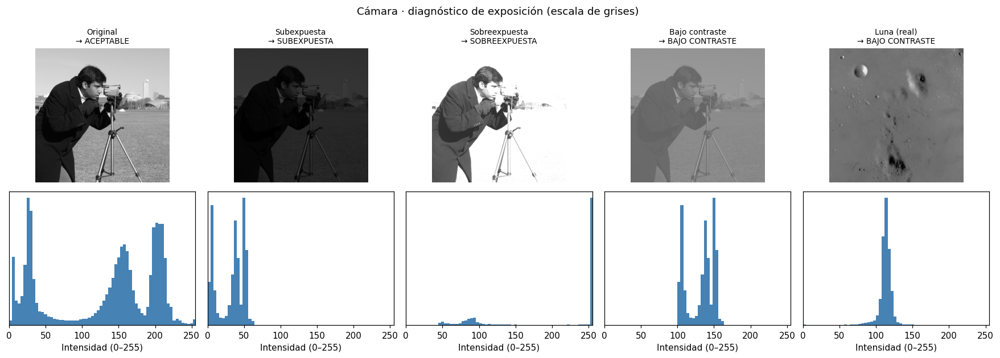

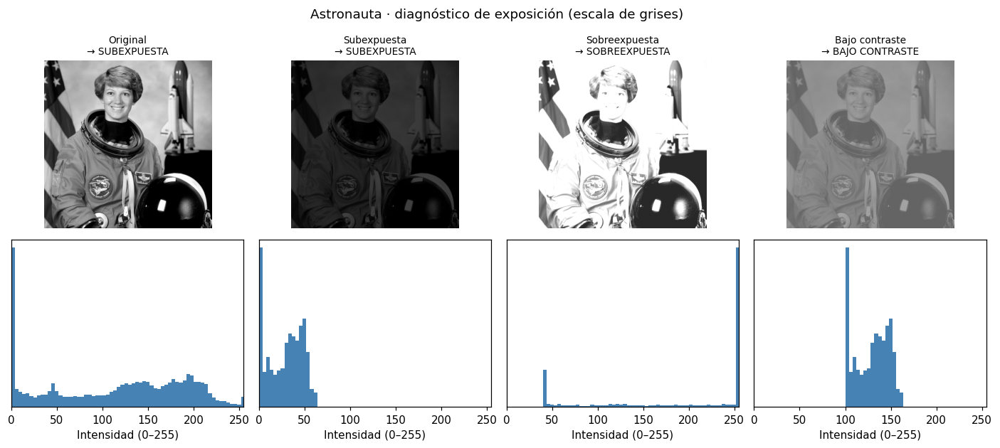

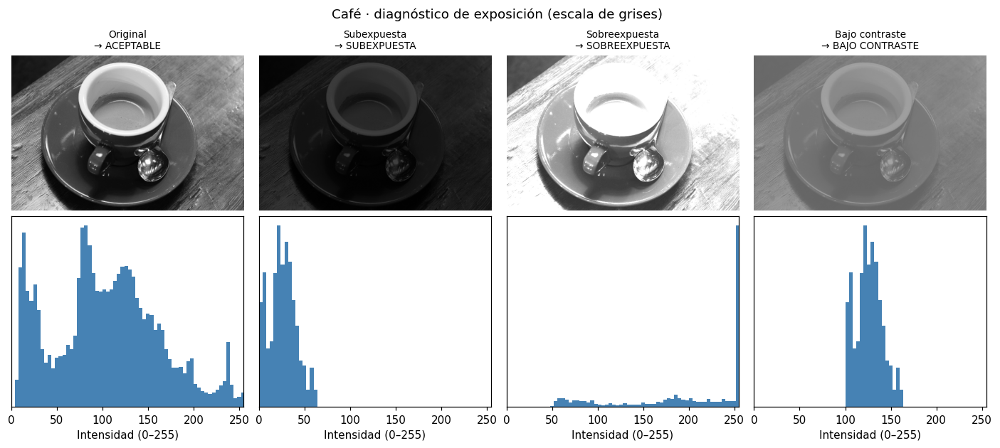

In [25]:
def diagnosticar(img):
    e = estadisticas_histograma(img)
    if e["recorte_blanco_%"] > 5 or e["media"] > 190: return "SOBREEXPUESTA"
    if e["recorte_negro_%"] > 5 or e["media"] < 60:   return "SUBEXPUESTA"
    if e["rango_dinamico"] < 100:                    return "BAJO CONTRASTE"
    return "ACEPTABLE"

# Las mismas transformaciones para tres escenas distintas.
# Convertimos RGB a gris para comparar histogramas de intensidad.
imagenes_42 = [("Cámara", camara),
               ("Astronauta", cv2.cvtColor(astronauta, cv2.COLOR_RGB2GRAY)),
               ("Café", cv2.cvtColor(cafe, cv2.COLOR_RGB2GRAY))]

for nombre_42, base_42 in imagenes_42:
    casos_42 = {"Original": base_42,
                "Subexpuesta": (base_42.astype(np.float32) * 0.25).astype(np.uint8),
                "Sobreexpuesta": np.clip(base_42.astype(float) * 1.8 + 40, 0, 255).astype(np.uint8),
                "Bajo contraste": (100 + base_42 * 0.25).astype(np.uint8)}
    # Mantener la luna como referencia real del ejemplo original.
    if nombre_42 == "Cámara":
        casos_42["Luna (real)"] = luna
        casos = casos_42
    fig, axes = plt.subplots(2, len(casos_42), figsize=(3.2 * len(casos_42), 5.8))
    fig.suptitle(f"{nombre_42} · diagnóstico de exposición (escala de grises)")
    for i, (nombre_caso, img_42) in enumerate(casos_42.items()):
        axes[0, i].imshow(img_42, cmap="gray", vmin=0, vmax=255)
        axes[0, i].axis("off")
        axes[0, i].set_title(f"{nombre_caso}\n→ {diagnosticar(img_42)}", fontsize=9)
        axes[1, i].hist(img_42.ravel(), bins=64, range=(0, 256), color="steelblue")
        axes[1, i].set_xlim(0, 255)
        axes[1, i].set_yticks([])
        axes[1, i].set_xlabel("Intensidad (0–255)")
    plt.tight_layout(); plt.show()


### 4.3 Brillo vs contraste
Brillo = desplazamiento (`g = f + β`); contraste = expansión alrededor de la media (`g = α(f − μ) + μ`). Ambos pueden saturar píxeles, y esa saturación es pérdida irreversible.

Compara **cámara, astronauta y café** en gris con los mismos parámetros: brillo +60 y contraste ×1.5. La media se calcula para cada imagen. Observa cómo se desplaza o se expande el histograma y cuánto aumenta la proporción de píxeles en los extremos. Los píxeles que ya estaban en los extremos en la imagen original no prueban por sí solos pérdida causada por la transformación.


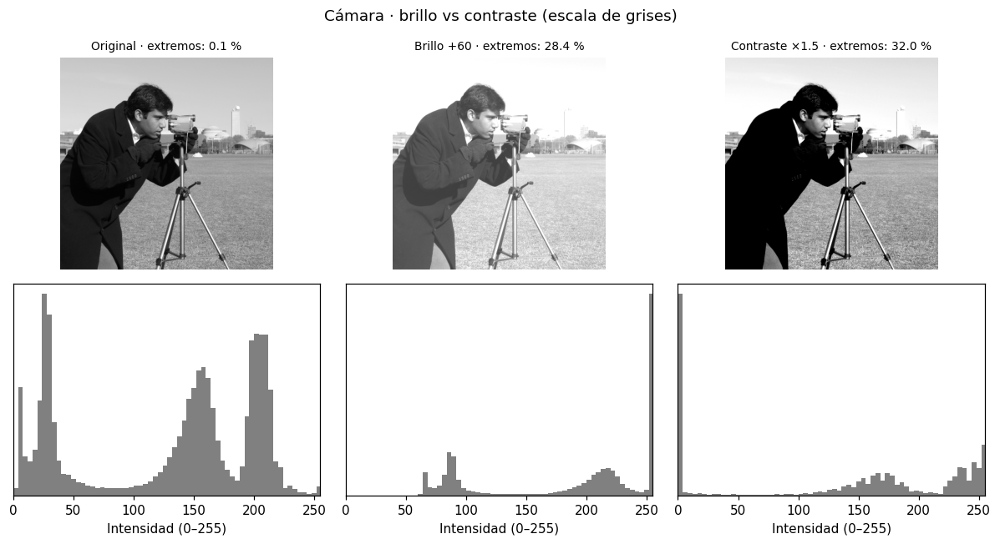

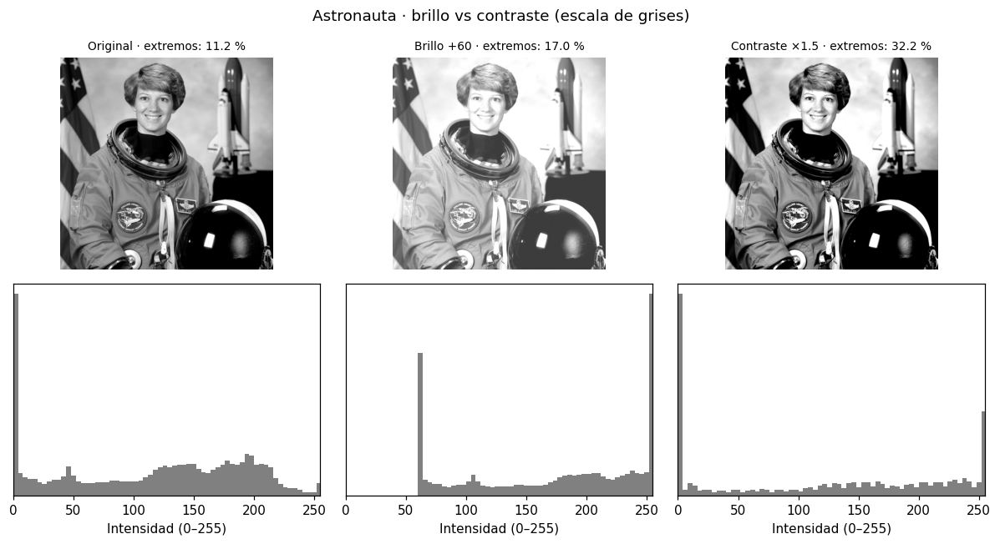

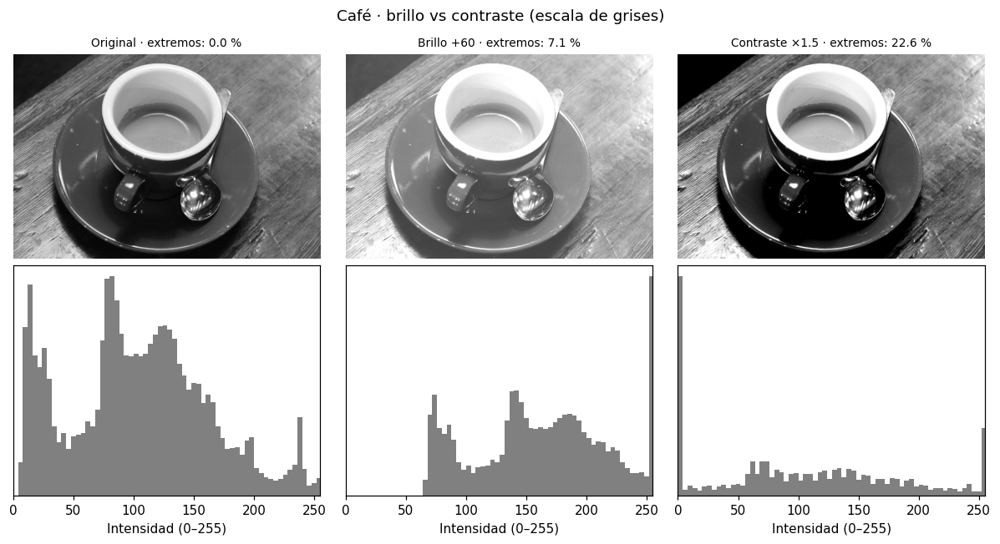

In [26]:
imagenes_43 = [("Cámara", camara),
               ("Astronauta", cv2.cvtColor(astronauta, cv2.COLOR_RGB2GRAY)),
               ("Café", cv2.cvtColor(cafe, cv2.COLOR_RGB2GRAY))]

for nombre_43, base_43 in imagenes_43:
    mu_43 = base_43.mean()
    brillo_43 = np.clip(base_43.astype(float) + 60, 0, 255).astype(np.uint8)
    contraste_43 = np.clip(1.5 * (base_43.astype(float) - mu_43) + mu_43, 0, 255).astype(np.uint8)
    if nombre_43 == "Cámara":
        mu, brillo, contraste = mu_43, brillo_43, contraste_43

    fig, axes = plt.subplots(2, 3, figsize=(11, 6))
    fig.suptitle(f"{nombre_43} · brillo vs contraste (escala de grises)")
    for i, (nombre_caso, img_43) in enumerate({"Original": base_43,
                 "Brillo +60": brillo_43, "Contraste ×1.5": contraste_43}.items()):
        e = estadisticas_histograma(img_43)
        axes[0, i].imshow(img_43, cmap="gray", vmin=0, vmax=255)
        axes[0, i].axis("off")
        axes[0, i].set_title(f"{nombre_caso} · extremos: {e['recorte_negro_%'] + e['recorte_blanco_%']:.1f} %", fontsize=9)
        axes[1, i].hist(img_43.ravel(), bins=64, range=(0, 256), color="gray")
        axes[1, i].set_xlim(0, 255)
        axes[1, i].set_yticks([])
        axes[1, i].set_xlabel("Intensidad (0–255)")
    plt.tight_layout(); plt.show()


### 4.4 Ecualización global implementada con la CDF
La transformación es `T(k) = round((CDF(k) − CDF_min) / (N − CDF_min) · 255)`. Verificamos que coincide con OpenCV y que la CDF resultante es aproximadamente lineal.

Coincidencia con cv2.equalizeHist: 100.00% de píxeles, diferencia máx. 0 nivel(es)


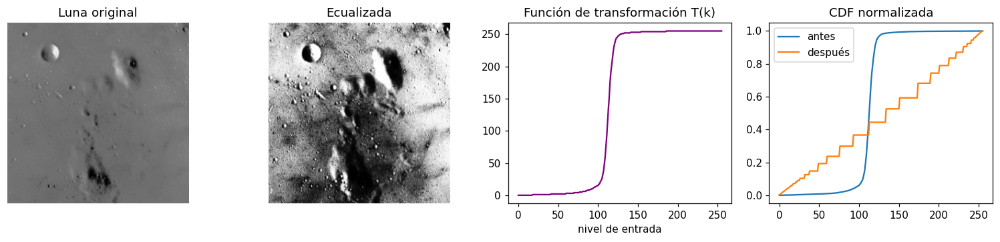

In [27]:
def ecualizar(img):
    cdf = np.bincount(img.ravel(), minlength=256).cumsum()
    if img.size == 0:
        raise ValueError("La imagen no puede estar vacía")
    cdf_min = cdf[cdf > 0][0]
    if cdf[-1] == cdf_min:
        return img.copy(), np.arange(256, dtype=np.uint8)
    lut = np.round((cdf - cdf_min) / (cdf[-1] - cdf_min) * 255).clip(0, 255).astype(np.uint8)
    return lut[img], lut

eq_manual, lut = ecualizar(luna)
eq_opencv = cv2.equalizeHist(luna)
print(f"Coincidencia con cv2.equalizeHist: {(eq_manual == eq_opencv).mean():.2%} de píxeles, "
      f"diferencia máx. {np.abs(eq_manual.astype(int) - eq_opencv).max()} nivel(es)")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
axes[0].imshow(luna, cmap="gray", vmin=0, vmax=255); axes[0].set_title("Luna original"); axes[0].axis("off")
axes[1].imshow(eq_manual, cmap="gray", vmin=0, vmax=255); axes[1].set_title("Ecualizada"); axes[1].axis("off")
axes[2].plot(lut, color="purple"); axes[2].set_title("Función de transformación T(k)"); axes[2].set_xlabel("nivel de entrada")
for img, n in [(luna, "antes"), (eq_manual, "después")]:
    cdf = np.bincount(img.ravel(), minlength=256).cumsum(); axes[3].plot(cdf / cdf[-1], label=n)
axes[3].legend(); axes[3].set_title("CDF normalizada")
plt.tight_layout(); plt.show()

### 4.5 Global vs CLAHE con iluminación desigual
Simulamos una escena iluminada solo por un lado y con ruido de sensor. Medimos la variación local en una zona de cielo. Su desviación mezcla textura, iluminación y ruido; no es una medición aislada del ruido del sensor.

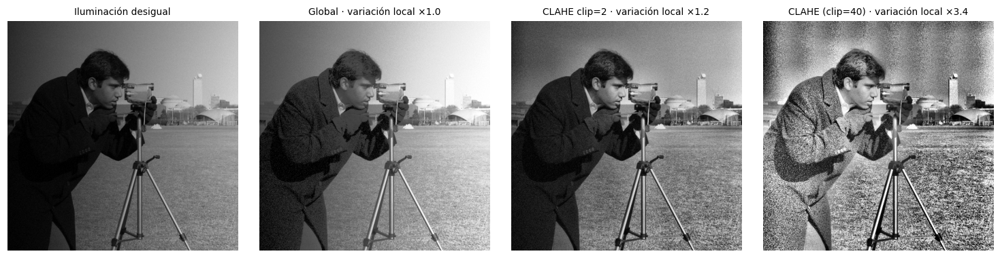

In [28]:
rng = np.random.default_rng(1)
luz = np.linspace(0.2, 1.0, camara.shape[1])[None, :]
desigual = np.clip(camara * luz + rng.normal(0, 3, camara.shape), 0, 255).astype(np.uint8)

global_eq  = cv2.equalizeHist(desigual)
clahe      = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(desigual)
ahe_sin_lim = cv2.createCLAHE(clipLimit=40.0, tileGridSize=(8, 8)).apply(desigual)

cielo = (slice(10, 60), slice(20, 120))       # zona plana a la izquierda (la más oscura)
base = desigual[cielo].std()
def amplif(img): return img[cielo].std() / base

mostrar([desigual, global_eq, clahe, ahe_sin_lim],
        ["Iluminación desigual", f"Global · variación local ×{amplif(global_eq):.1f}",
         f"CLAHE clip=2 · variación local ×{amplif(clahe):.1f}", f"CLAHE (clip=40) · variación local ×{amplif(ahe_sin_lim):.1f}"], tam=3.4)

### 4.6 El histograma no conserva la posición (PDF 49-50)
Dos imágenes pueden tener exactamente el mismo histograma y estructuras distintas.
Frecuencia del histograma significa conteo de píxeles, no frecuencia espacial de Fourier.

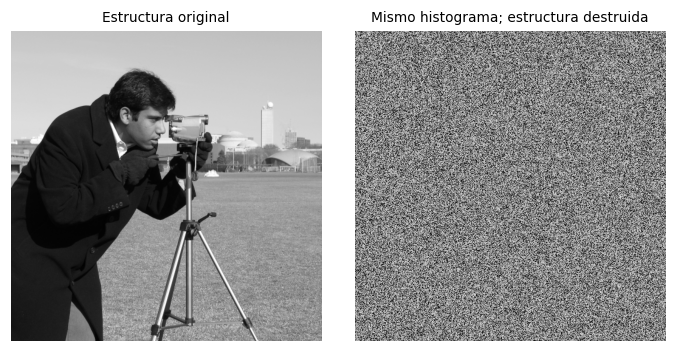

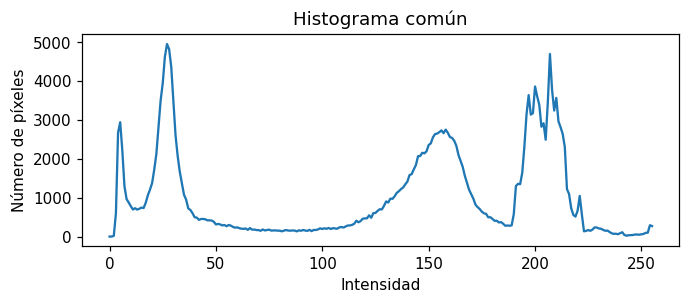

In [29]:
mezclada47 = np.random.default_rng(47).permutation(camara.ravel()).reshape(camara.shape)
assert np.array_equal(np.bincount(camara.ravel(),minlength=256),np.bincount(mezclada47.ravel(),minlength=256))
mostrar([camara,mezclada47],["Estructura original", "Mismo histograma; estructura destruida"])
fig,ax=plt.subplots(figsize=(7,2.5))
ax.plot(np.bincount(camara.ravel(),minlength=256));ax.set(xlabel="Intensidad",ylabel="Número de píxeles",title="Histograma común")
plt.show()

### 4.7 CLAHE en una escena vascular sintética (PDF 56)
Usamos un fondo de ojo **sintético**, sin datos de pacientes ni descargas.
El caso muestra contraste local y su sensibilidad al parámetro de recorte;
no demuestra mejora diagnóstica ni recuperación de estructuras ausentes.

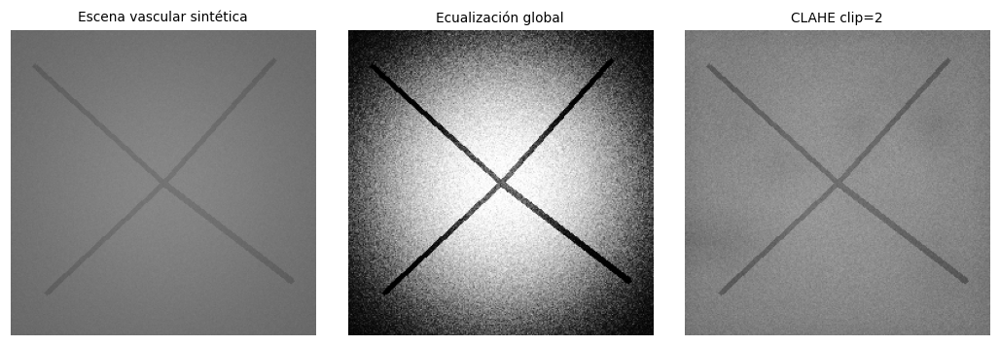

In [30]:
yy48,xx48=np.mgrid[:256,:256]
retina48=np.clip(100+35*np.exp(-((xx48-128)**2+(yy48-128)**2)/18000),0,255).astype(np.uint8)
mascara48=np.zeros((256,256),np.uint8)
for extremo in [(20,30),(30,220),(220,25),(235,210)]:
    cv2.line(mascara48,(128,128),extremo,255,3)
retina48[mascara48>0]-=18
retina48=np.clip(retina48.astype(float)+np.random.default_rng(48).normal(0,2,(256,256)),0,255).astype(np.uint8)
mostrar([retina48,cv2.equalizeHist(retina48),cv2.createCLAHE(2,(8,8)).apply(retina48)],
        ["Escena vascular sintética", "Ecualización global", "CLAHE clip=2"])

**Para discutir en clase**
1. Los umbrales de `diagnosticar()` son fijos. ¿Cómo los calibrarían con datos de su propio dominio?
2. En imágenes médicas, ¿qué riesgo tiene la ecualización global frente a CLAHE? ¿Y CLAHE frente a no hacer nada?
3. Si el 80 % de las fotos de una clase se tomó de noche, ¿qué aprendería el modelo? (Lo medimos en el Ejemplo 7.)

---
# Ejemplo 5 · Preprocesamiento y normalización de imágenes para modelos de IA

**Objetivo.** Construir un pipeline que convierta imágenes heterogéneas en tensores homogéneos, normalizar sin fuga de información, demostrar numéricamente por qué la normalización importa para la convergencia y aplicar *augmentation* respetando la semántica de la clase.

### 5.1 Homogeneización: formatos heterogéneos → RGB uint8 → tamaño fijo
En un proyecto real conviven imágenes en gris, RGB, RGBA (con transparencia) y de 16 bits (médicas, científicas).

,imagen,forma,dtype,canales,aspecto,máximo
0,astronauta (RGB),"(512, 512, 3)",uint8,3,1.0,255
1,cámara (gris),"(512, 512)",uint8,1,1.0,255
2,logo (RGBA),"(500, 500, 4)",uint8,4,1.0,255
3,cohete (RGB 4:3),"(427, 640, 3)",uint8,3,1.5,255
4,cámara 16 bits,"(512, 512)",uint16,1,1.0,65535
5,células (RGB),"(512, 512, 3)",uint8,3,1.0,255


Lote homogéneo: (6, 224, 224, 3) uint8


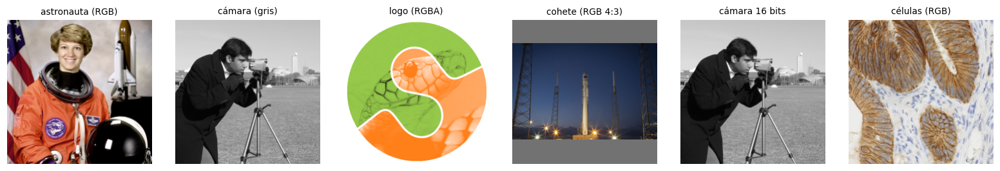

In [31]:
coleccion = {"astronauta (RGB)": astronauta, "cámara (gris)": camara, "logo (RGBA)": data.logo(),
             "cohete (RGB 4:3)": data.rocket(), "cámara 16 bits": (camara.astype(np.uint16) * 257),
             "células (RGB)": data.immunohistochemistry()}

def a_rgb_uint8(img):
    if img.dtype == np.uint16:
        img = (img / 257).round().astype(np.uint8)
    elif np.issubdtype(img.dtype, np.floating):
        img = (np.clip(img, 0, 1) * 255).round().astype(np.uint8)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    elif img.shape[2] == 4:                                   # componer sobre fondo blanco usando alfa
        alfa = img[..., 3:4].astype(np.float32) / 255
        img = (img[..., :3] * alfa + 255 * (1 - alfa)).round().astype(np.uint8)
    return img

inventario = pd.DataFrame([{"imagen": n, "forma": img.shape, "dtype": str(img.dtype),
                            "canales": 1 if img.ndim == 2 else img.shape[2],
                            "aspecto": round(img.shape[1] / img.shape[0], 2), "máximo": int(img.max())}
                           for n, img in coleccion.items()])
display(inventario)

homogeneas = [ajustar_tamano(a_rgb_uint8(img), 224)[0] for img in coleccion.values()]
lote = np.stack(homogeneas)                     # (N, 224, 224, 3) uint8
print("Lote homogéneo:", lote.shape, lote.dtype)
mostrar(homogeneas, list(coleccion), cols=6, tam=2.4)

### 5.2 Normalización sin fuga de información
Las estadísticas (media y desviación por canal) se calculan **solo con entrenamiento** y luego se aplican a validación y prueba, igual que un `StandardScaler`. El cálculo se hace de forma acumulativa para que funcione con datasets que no caben en memoria.

Este mini-dataset tiene recortes de solo dos fotografías: sirve para estudiar
estadísticas y optimización, **no** para estimar generalización a fotografías
nuevas. El ejemplo 6 separa por objeto. La validación utiliza las estadísticas
del entrenamiento; lo prohibido es ajustarlas con validación o prueba.


In [32]:
class NormalizadorCanales:
    """Media/desviación por canal calculadas en streaming. fit() solo con entrenamiento."""
    def fit(self, imagenes):
        suma = np.zeros(3); suma_cuad = np.zeros(3); n = 0
        for img in imagenes:                                   # una a una: no requiere cargar todo
            x = img.reshape(-1, 3).astype(np.float64) / 255
            suma += x.sum(0); suma_cuad += (x ** 2).sum(0); n += x.shape[0]
        if n == 0:
            raise ValueError("No hay píxeles de entrenamiento")
        self.media = suma / n
        self.std = np.sqrt(np.maximum(suma_cuad / n - self.media ** 2, 1e-12))
        return self
    def transform(self, lote_uint8):                           # (N, H, W, 3) uint8 → (N, 3, H, W) float32
        x = lote_uint8.astype(np.float32) / 255
        x = (x - self.media) / self.std
        return x.transpose(0, 3, 1, 2).astype(np.float32)
    def guardar(self, ruta):
        json.dump({"media": self.media.tolist(), "std": self.std.tolist()}, open(ruta, "w"))

# Mini-dataset: 400 recortes 64×64 de dos fuentes con condiciones de luz distintas
rng = np.random.default_rng(3)
def recortes(img, n, tam=64, factor=(0.6, 1.4)):
    h, w = img.shape[:2]; out = []
    for _ in range(n):
        y, x = rng.integers(0, h - tam), rng.integers(0, w - tam)
        out.append(np.clip(img[y:y+tam, x:x+tam] * rng.uniform(*factor), 0, 255).astype(np.uint8))
    return out
X = np.stack(recortes(cafe, 200) + recortes(gato, 200)); y = np.array([0] * 200 + [1] * 200)
idx = rng.permutation(len(X)); ent, val = idx[:300], idx[300:]

norm_correcto = NormalizadorCanales().fit(X[ent])
norm_con_fuga = NormalizadorCanales().fit(X)                   # ✗ incluye validación
norm_correcto.guardar(SALIDAS / "estadisticas_normalizacion.json")

print("Media (solo train)   :", norm_correcto.media.round(4), "| std:", norm_correcto.std.round(4))
print("Media (train + val) ✗:", norm_con_fuga.media.round(4))
print("Referencia ImageNet  :", [0.485, 0.456, 0.406], "| std:", [0.229, 0.224, 0.225])
xt, xv = norm_correcto.transform(X[ent]), norm_correcto.transform(X[val])
print(f"Train normalizado → media {xt.mean():+.3f}, std {xt.std():.3f}   (≈0 y ≈1 por construcción)")
print(f"Val normalizado   → media {xv.mean():+.3f}, std {xv.std():.3f}   (cercano, no exacto: eso es lo esperado)")

Media (solo train)   : [0.5864 0.3762 0.2515] | std: [0.2352 0.2154 0.1932]
Media (train + val) ✗: [0.5888 0.3715 0.2469]
Referencia ImageNet  : [0.485, 0.456, 0.406] | std: [0.229, 0.224, 0.225]
Train normalizado → media +0.000, std 1.000   (≈0 y ≈1 por construcción)
Val normalizado   → media -0.047, std 1.023   (cercano, no exacto: eso es lo esperado)


### 5.3 Comparación de escalas numéricas
Comparamos los valores originales, la división entre 255 y la estandarización
con media y desviación del entrenamiento. Estas operaciones ajustan la escala
de entrada utilizada por el modelo.

In [33]:
escalas53={"Original [0,255]":X[ent].astype(np.float32),
           "División entre 255":X[ent].astype(np.float32)/255,
           "Z-score de entrenamiento":xt}
display(pd.DataFrame({nombre:{"Mínimo":float(a.min()),"Máximo":float(a.max()),
                              "Media":float(a.mean()),"Desviación":float(a.std())}
                      for nombre,a in escalas53.items()}).T.round(3))

,Mínimo,Máximo,Media,Desviación
"Original [0,255]",0.000,255.000,103.197,65.239
División entre 255,0.000,1.000,0.405,0.256
Z-score de entrenamiento,-2.493,3.874,0.000,1.000


### 5.4 *Augmentation* con restricción semántica
Una transformación es válida solo si **no cambia la etiqueta**. En un clasificador de dirección de flechas, el volteo horizontal convierte "derecha" en "izquierda" sin cambiar la etiqueta: el dataset queda contaminado. Lo mismo ocurre con 6/9 al rotar 180°, con texto (OCR) al voltear, o con órganos lateralizados en imágenes médicas.

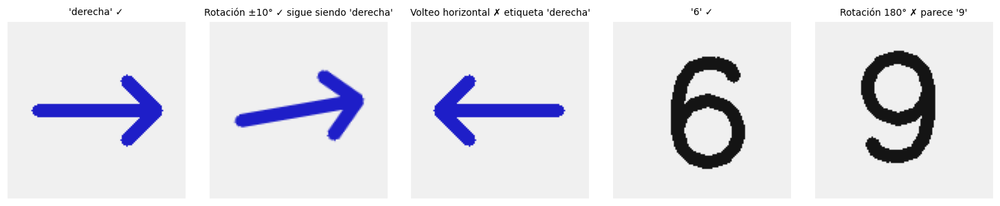

In [34]:
def flecha(direccion="derecha"):
    img = np.full((120, 120, 3), 240, np.uint8)
    ini, fin = ((20, 60), (100, 60)) if direccion == "derecha" else ((100, 60), (20, 60))
    cv2.arrowedLine(img, ini, fin, (30, 30, 200), 8, tipLength=0.35)
    return img

def digito(d):
    img = np.full((120, 120, 3), 240, np.uint8)
    cv2.putText(img, str(d), (30, 95), cv2.FONT_HERSHEY_SIMPLEX, 3.2, (20, 20, 20), 8)
    return img

f_der = flecha("derecha")
rot_leve = cv2.warpAffine(f_der, cv2.getRotationMatrix2D((60, 60), 10, 1), (120, 120), borderValue=(240, 240, 240))
seis = digito(6)
mostrar([f_der, rot_leve, cv2.flip(f_der, 1), seis, cv2.rotate(seis, cv2.ROTATE_180)],
        ["'derecha' ✓", "Rotación ±10° ✓ sigue siendo 'derecha'", "Volteo horizontal ✗ etiqueta 'derecha'",
         "'6' ✓", "Rotación 180° ✗ parece '9'"], cols=5, tam=2.7)

### 5.5 Auditoría automática del tensor antes de entrenar
Una función de verificación que conviene ejecutar sobre el primer lote de cada `DataLoader`. Acepta arreglos de NumPy o tensores de PyTorch.

In [35]:
def auditar_lote(x, tolerancia_media=0.5, tolerancia_std=0.5):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    if x.ndim != 4 or x.size == 0:
        print("  ❌ Se necesita un lote no vacío (N,C,H,W)")
        return False
    checks = {
        "4 dimensiones (N, C, H, W)":        x.ndim == 4,
        "3 canales en la posición 1":        x.ndim == 4 and x.shape[1] == 3,
        "tipo float32":                      x.dtype == np.float32,
        "sin NaN ni infinitos":              bool(np.isfinite(x).all()),
        "no parece crudo en [0, 255]":       float(x.max()) < 20,
        "media por canal ≈ 0":               bool(np.all(np.abs(x.mean(axis=(0, 2, 3))) < tolerancia_media)),
        "std por canal ≈ 1":                 bool(np.all(np.abs(x.std(axis=(0, 2, 3)) - 1) < tolerancia_std)),
    }
    for k, ok in checks.items():
        print(("  ✅ " if ok else "  ❌ ") + k)
    if checks["3 canales en la posición 1"]:
        print(f"  forma {x.shape} · media/canal {x.mean(axis=(0, 2, 3)).round(3)} · std/canal {x.std(axis=(0, 2, 3)).round(3)}")
    else:
        print(f"  forma {x.shape} · rango [{x.min():.1f}, {x.max():.1f}]")
    return all(checks.values())

print("Lote bien preparado:"); auditar_lote(norm_correcto.transform(X[ent[:32]]))
print("\nLote con error típico (se olvidó normalizar y quedó HWC):"); auditar_lote(X[ent[:32]].astype(np.float32))

Lote bien preparado:
  ✅ 4 dimensiones (N, C, H, W)
  ✅ 3 canales en la posición 1
  ✅ tipo float32
  ✅ sin NaN ni infinitos
  ✅ no parece crudo en [0, 255]
  ✅ media por canal ≈ 0
  ✅ std por canal ≈ 1
  forma (32, 3, 64, 64) · media/canal [0.074 0.189 0.176] · std/canal [1.041 1.066 1.086]

Lote con error típico (se olvidó normalizar y quedó HWC):
  ✅ 4 dimensiones (N, C, H, W)
  ❌ 3 canales en la posición 1
  ✅ tipo float32
  ✅ sin NaN ni infinitos
  ❌ no parece crudo en [0, 255]
  ❌ media por canal ≈ 0
  ❌ std por canal ≈ 1
  forma (32, 64, 64, 3) · rango [0.0, 255.0]


False

### 5.6 Pipeline de producción con `torchvision.transforms.v2`
El pipeline de entrenamiento incluye *augmentation* aleatorio; el de validación es determinista. Para modelos preentrenados se usan las estadísticas de ImageNet; para modelos entrenados desde cero, las propias de entrenamiento (5.2).

Las medias/std de ImageNet aquí son un ejemplo concreto. Debe consultarse la
configuración de los pesos elegidos. Un lote de otro dominio no tiene por qué
dar media cero y std uno: esos indicadores de la auditoría son heurísticos.


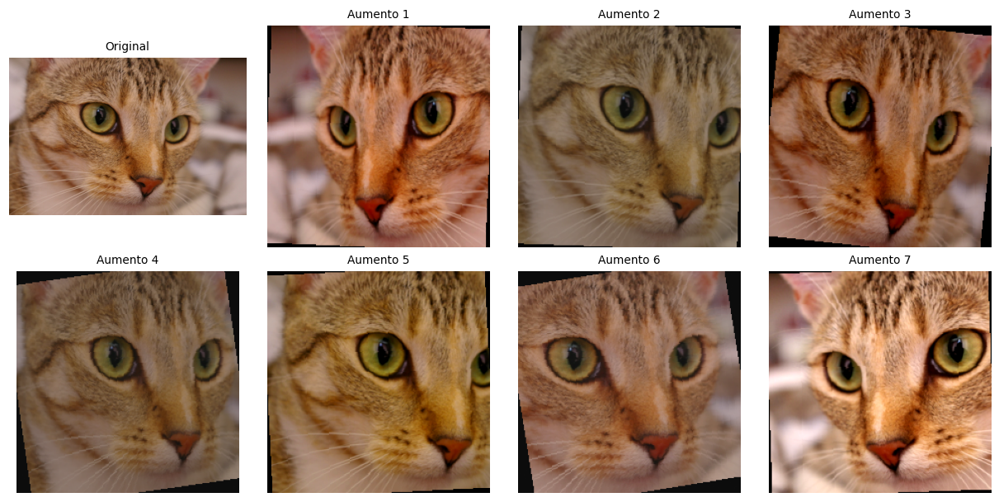

Auditoría de un lote de entrenamiento aumentado:
  ✅ 4 dimensiones (N, C, H, W)
  ✅ 3 canales en la posición 1
  ✅ tipo float32
  ✅ sin NaN ni infinitos
  ✅ no parece crudo en [0, 255]
  ✅ media por canal ≈ 0
  ✅ std por canal ≈ 1
  forma (7, 3, 224, 224) · media/canal [ 0.184 -0.351 -0.608] · std/canal [0.796 0.68  0.678]


True

In [36]:
import torch
from torchvision.transforms import v2

MEDIA_IMAGENET, STD_IMAGENET = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

tf_entrenamiento = v2.Compose([
    v2.ToImage(),
    v2.RandomResizedCrop(224, scale=(0.6, 1.0), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),                 # válido para gatos; NO para flechas, texto o dígitos
    v2.RandomRotation(12),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.02),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(MEDIA_IMAGENET, STD_IMAGENET)])

tf_validacion = v2.Compose([
    v2.ToImage(), v2.Resize(256, antialias=True), v2.CenterCrop(224),
    v2.ToDtype(torch.float32, scale=True), v2.Normalize(MEDIA_IMAGENET, STD_IMAGENET)])

def desnormalizar(t, media=MEDIA_IMAGENET, std=STD_IMAGENET):
    m, s = torch.tensor(media).view(3, 1, 1), torch.tensor(std).view(3, 1, 1)
    return (t * s + m).clamp(0, 1).permute(1, 2, 0).numpy()

pil = Image.fromarray(gato)
torch.manual_seed(0)
aumentadas = [tf_entrenamiento(pil) for _ in range(7)]
mostrar([gato] + [desnormalizar(t) for t in aumentadas], ["Original"] + [f"Aumento {i+1}" for i in range(7)], cols=4, tam=2.8)

print("Auditoría de un lote de entrenamiento aumentado:")
auditar_lote(torch.stack(aumentadas), tolerancia_media=1.0)

### 5.7 Corregir orientación EXIF antes de redimensionar (PDF 60)
Se crea un JPEG de demostración cuya orientación vive en los metadatos.
Primero se aplica `exif_transpose`, después la conversión a RGB y el ajustar_tamano.

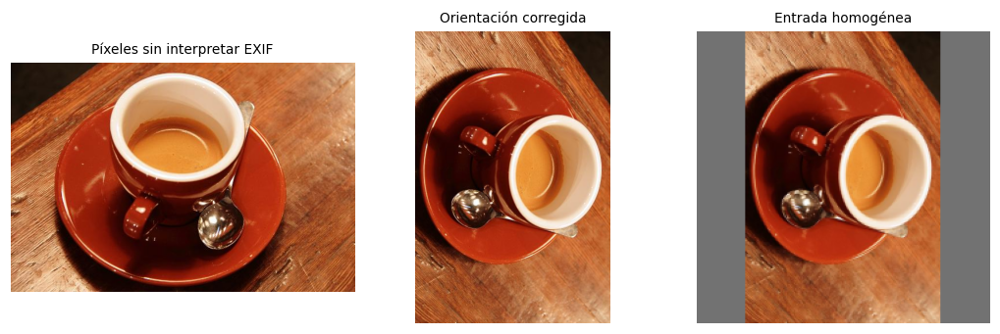

In [37]:
ruta57=SALIDAS/'orientacion_demo.jpg'
exif57=Image.Exif();exif57[274]=6
Image.fromarray(cafe).save(ruta57,exif=exif57)
with Image.open(ruta57) as im57:
    cruda57=np.array(im57)
    orientada57=np.array(ImageOps.exif_transpose(im57).convert('RGB'))
assert orientada57.shape[:2] == cruda57.shape[:2][::-1]
mostrar([cruda57,orientada57,ajustar_tamano(orientada57,224)[0]], ["Píxeles sin interpretar EXIF", "Orientación corregida", "Entrada homogénea"])

### 5.8 Traslación, ruido y oclusión controlada (PDF 63-65)
Los aumentos se aplican solo al entrenamiento. La clase debe seguir siendo
reconocible; cajas y máscaras requieren la misma transformación geométrica.

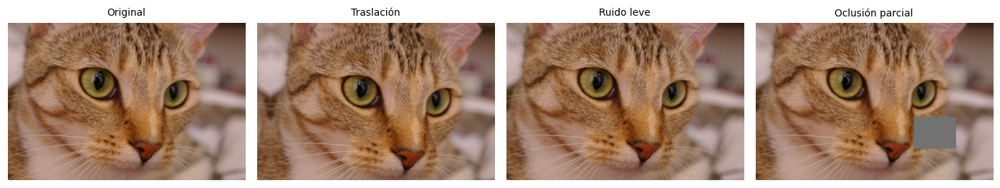

In [38]:
rng58=np.random.default_rng(58)
tras58=cv2.warpAffine(gato,np.float32([[1,0,25],[0,1,15]]),(gato.shape[1],gato.shape[0]),borderMode=cv2.BORDER_REFLECT)
ruido58=np.clip(gato.astype(float)+rng58.normal(0,8,gato.shape),0,255).astype(np.uint8)
oclu58=gato.copy();oclu58[180:240,300:380]=114
mostrar([gato,tras58,ruido58,oclu58],["Original", "Traslación", "Ruido leve", "Oclusión parcial"])

**Para discutir en clase**
1. ¿Por qué la media y desviación deben calcularse solo con entrenamiento?
2. ¿Qué diferencias observas entre dividir entre 255 y aplicar Z-score?
3. ¿Qué aumentos cambiarían la etiqueta de una flecha, un dígito o un órgano lateralizado?

---
# Ejemplo 6 · Construcción de datasets de imágenes

**Objetivo.** Construir un dataset completo con estructura de carpetas, convención de nombres, metadatos y trazabilidad; particionarlo sin fuga de información y comprobar que los objetos no se comparten entre particiones. Terminamos con el `Dataset` de PyTorch y el balanceo de clases.

### 6.1 Generación del dataset
Simulamos la captura de figuras geométricas (círculo, cuadrado, triángulo). Cada **objeto físico** se fotografía 5 veces con pequeñas variaciones de posición, ángulo y luz: esas 5 tomas forman un **grupo**. Además:

- hay **desbalance** intencional (60, 40 y 16 objetos por clase);
- las fotos se tomaron en dos lugares con fondos distintos (`lab_A` azulado, `lab_B` cálido), y los círculos se fotografiaron mayormente en `lab_A`. Es un sesgo oculto que detectaremos en el Ejemplo 7.

580 imágenes · 116 objetos físicos


,ruta,clase,objeto_id,toma,lugar,ancho,alto,sha256
0,raw/circulo/circulo_obj000_toma0.png,circulo,circulo_obj000,0,lab_A,128,128,3f5e453f6f227dffbd14be4f80ef6dd04c2c1162d9a564...
1,raw/circulo/circulo_obj000_toma1.png,circulo,circulo_obj000,1,lab_A,128,128,dbfb4f0846134fdaa4c0bd2fe39adc2085b85fa73bc170...
2,raw/circulo/circulo_obj000_toma2.png,circulo,circulo_obj000,2,lab_A,128,128,f706b0296421122070f207e23bf1ce45b76abb05f66fe4...


,imagenes,objetos
clase,,
circulo,300,60
cuadrado,200,40
triangulo,80,16


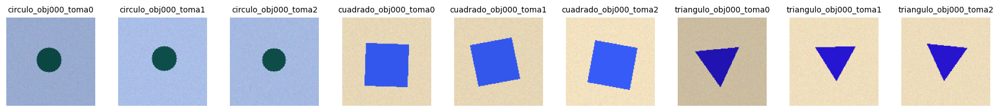

In [39]:
RAIZ = SALIDAS / "dataset_formas"
RAIZ.mkdir(parents=True, exist_ok=True)
TAM, TOMAS = 128, 5
CLASES = ["circulo", "cuadrado", "triangulo"]
N_OBJETOS = {"circulo": 60, "cuadrado": 40, "triangulo": 16}
FONDOS = {"lab_A": (165, 185, 225), "lab_B": (215, 200, 170)}
P_LAB_A = {"circulo": 0.8, "cuadrado": 0.25, "triangulo": 0.25}   # sesgo de captura
luma = lambda c: 0.299 * c[0] + 0.587 * c[1] + 0.114 * c[2]

def dibujar_forma(clase, color, lado, angulo, centro, fondo, brillo, rng):
    img = np.empty((TAM, TAM, 3), np.float32); img[:] = fondo
    img += rng.normal(0, 6, img.shape)                                 # textura/ruido del fondo
    cx, cy = centro
    if clase == "circulo":
        cv2.circle(img, (int(cx), int(cy)), int(lado / 2), color, -1, lineType=cv2.LINE_AA)
    elif clase == "cuadrado":
        pts = cv2.boxPoints(((cx, cy), (lado, lado), angulo)).astype(np.int32)
        cv2.fillPoly(img, [pts], color, lineType=cv2.LINE_AA)
    else:
        r = lado * 0.65
        ang = np.deg2rad(angulo + np.array([90, 210, 330]))
        pts = np.stack([cx + r * np.cos(ang), cy - r * np.sin(ang)], 1).astype(np.int32)
        cv2.fillPoly(img, [pts], color, lineType=cv2.LINE_AA)
    return np.clip(img * brillo, 0, 255).astype(np.uint8)

rng = np.random.default_rng(7)
registros = []
for clase in CLASES:
    (RAIZ / "raw" / clase).mkdir(parents=True)
    for obj in range(N_OBJETOS[clase]):
        lugar = "lab_A" if rng.random() < P_LAB_A[clase] else "lab_B"
        fondo = FONDOS[lugar]
        while True:                                                     # color con contraste suficiente
            color = tuple(float(v) for v in rng.integers(0, 256, 3))
            if abs(luma(color) - luma(fondo)) > 60: break
        lado_base, ang_base = rng.uniform(36, 64), rng.uniform(0, 90)
        for toma in range(TOMAS):
            img = dibujar_forma(clase, color, lado_base * rng.uniform(0.92, 1.08), ang_base + rng.uniform(-15, 15),
                                (64 + rng.uniform(-6, 6), 64 + rng.uniform(-6, 6)), fondo, rng.uniform(0.85, 1.15), rng)
            nombre = f"{clase}_obj{obj:03d}_toma{toma}.png"             # convención: clase_objeto_toma
            ruta = Path("raw") / clase / nombre
            cv2.imwrite(str(RAIZ / ruta), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            registros.append({"ruta": str(ruta), "clase": clase, "objeto_id": f"{clase}_obj{obj:03d}",
                              "toma": toma, "lugar": lugar, "ancho": TAM, "alto": TAM,
                              "sha256": hashlib.sha256((RAIZ / ruta).read_bytes()).hexdigest()})

meta = pd.DataFrame(registros)
meta.to_csv(RAIZ / "metadata.csv", index=False)
print(f"{len(meta)} imágenes · {meta.objeto_id.nunique()} objetos físicos")
display(meta.head(3))
display(meta.groupby("clase").agg(imagenes=("ruta", "count"), objetos=("objeto_id", "nunique")))

ejemplos = [cv2.cvtColor(cv2.imread(str(RAIZ / r)), cv2.COLOR_BGR2RGB)
            for r in meta.groupby("clase").head(3).ruta]
mostrar(ejemplos, [Path(r).stem for r in meta.groupby("clase").head(3).ruta], cols=9, tam=1.8)

### 6.2 Particiones independientes: 80/10/10
Comparamos separar imágenes individualmente con separar primero los objetos.
Todas las tomas de un mismo objeto deben quedar en una sola partición.
Las proporciones son aproximadas por el redondeo de grupos.

In [40]:
from sklearn.model_selection import train_test_split
tr,tmp=train_test_split(meta.index,test_size=.2,stratify=meta.clase,random_state=0)
va,te=train_test_split(tmp,test_size=.5,stratify=meta.loc[tmp,'clase'],random_state=0)
ingenua=pd.Series('train',index=meta.index);ingenua[va]='val';ingenua[te]='test'
def split_por_grupos(df,semilla=0):
    objetos=df[['objeto_id','clase']].drop_duplicates()
    entren,resto=train_test_split(objetos,test_size=.2,stratify=objetos.clase,random_state=semilla)
    valida,prueba=train_test_split(resto,test_size=.5,stratify=resto.clase,random_state=semilla)
    asignacion={obj:p for p,tabla in [('train',entren),('val',valida),('test',prueba)] for obj in tabla.objeto_id}
    return df.objeto_id.map(asignacion)
por_grupos=split_por_grupos(meta)
def objetos_filtrados(part):
    return int((meta.assign(p=part).groupby('objeto_id').p.nunique()>1).sum())
print('Objetos compartidos entre particiones:')
print('División por imagen:',objetos_filtrados(ingenua))
print('División por objeto:',objetos_filtrados(por_grupos))
assert objetos_filtrados(por_grupos)==0
display(pd.crosstab(por_grupos,meta.clase))

Objetos compartidos entre particiones:
División por imagen: 75
División por objeto: 0


clase,circulo,cuadrado,triangulo
objeto_id,,,
test,35,20,5
train,235,160,65
val,30,20,10


### 6.3 Exportar la estructura final y los manifiestos
Estructura compatible con `torchvision.datasets.ImageFolder` y un CSV de particiones versionable.

In [41]:
particiones = meta.assign(particion=por_grupos)
particiones.to_csv(RAIZ / "splits.csv", index=False)
for r in particiones.itertuples():
    destino = RAIZ / "splits" / r.particion / r.clase
    destino.mkdir(parents=True, exist_ok=True)
    shutil.copy(RAIZ / r.ruta, destino / Path(r.ruta).name)

for p in ["train", "val", "test"]:
    print(f"dataset_formas/splits/{p}/ ", {c: len(list((RAIZ / 'splits' / p / c).glob('*.png'))) for c in CLASES})

# Estadísticas de normalización calculadas SOLO con train (reutilizamos el normalizador del Ejemplo 5)
imgs_train = [cv2.cvtColor(cv2.imread(str(RAIZ / r)), cv2.COLOR_BGR2RGB) for r in particiones.query("particion == 'train'").ruta]
norm_formas = NormalizadorCanales().fit(imgs_train)
norm_formas.guardar(RAIZ / "normalizacion_train.json")

# Pesos por clase para la función de pérdida: N / (K · n_c)
conteo = particiones.query("particion == 'train'").clase.value_counts().reindex(CLASES)
pesos_clase = len(imgs_train) / (len(CLASES) * conteo)
print("\nMedia/std de train:", norm_formas.media.round(3), norm_formas.std.round(3))
print("Pesos por clase para CrossEntropyLoss:", pesos_clase.round(3).to_dict())

dataset_formas/splits/train/  {'circulo': 235, 'cuadrado': 160, 'triangulo': 65}
dataset_formas/splits/val/  {'circulo': 30, 'cuadrado': 20, 'triangulo': 10}
dataset_formas/splits/test/  {'circulo': 35, 'cuadrado': 20, 'triangulo': 5}

Media/std de train: [0.696 0.687 0.732] [0.183 0.187 0.199]
Pesos por clase para CrossEntropyLoss: {'circulo': 0.652, 'cuadrado': 0.958, 'triangulo': 2.359}


### 6.4 `Dataset` de PyTorch con muestreo balanceado
`WeightedRandomSampler` hace que cada clase aparezca con la misma frecuencia esperada en cada época, sin duplicar archivos en disco.

In [42]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.transforms import v2

class DatasetFormas(Dataset):
    def __init__(self, df, raiz, transform=None):
        self.df, self.raiz, self.transform = df.reset_index(drop=True), Path(raiz), transform
        self.clase_a_idx = {c: i for i, c in enumerate(CLASES)}
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        fila = self.df.iloc[i]
        img = Image.open(self.raiz / fila["ruta"]).convert("RGB")   # PIL → RGB, sin sorpresas BGR
        return (self.transform(img) if self.transform else img), self.clase_a_idx[fila["clase"]]

tf_formas = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
                        v2.Normalize(norm_formas.media.tolist(), norm_formas.std.tolist())])

entren = particiones.query("particion == 'train'")
pesos_muestra = entren.clase.map(1.0 / entren.clase.value_counts()).to_numpy(dtype=float, copy=True)
sampler = WeightedRandomSampler(torch.as_tensor(pesos_muestra, dtype=torch.double), num_samples=len(entren), replacement=True)

dl_sin = DataLoader(DatasetFormas(entren, RAIZ, tf_formas), batch_size=32, shuffle=True)
dl_bal = DataLoader(DatasetFormas(entren, RAIZ, tf_formas), batch_size=32, sampler=sampler)

torch.manual_seed(0)
for n, dl in [("Sin balancear", dl_sin), ("WeightedRandomSampler", dl_bal)]:
    vistos = torch.cat([yb for _, yb in dl])
    print(f"{n:<22} muestras por clase en una época: {dict(zip(CLASES, torch.bincount(vistos, minlength=3).tolist()))}")

xb, yb = next(iter(dl_bal))
print("\nAuditoría del primer lote:"); auditar_lote(xb)

Sin balancear          muestras por clase en una época: {'circulo': 235, 'cuadrado': 160, 'triangulo': 65}
WeightedRandomSampler  muestras por clase en una época: {'circulo': 147, 'cuadrado': 173, 'triangulo': 140}

Auditoría del primer lote:
  ✅ 4 dimensiones (N, C, H, W)
  ✅ 3 canales en la posición 1
  ✅ tipo float32
  ✅ sin NaN ni infinitos
  ✅ no parece crudo en [0, 255]
  ✅ media por canal ≈ 0
  ✅ std por canal ≈ 1
  forma (32, 3, 128, 128) · media/canal [ 0.148 -0.006 -0.192] · std/canal [0.983 1.061 0.973]


True

### 6.5 Clasificación, detección y segmentación: protocolo de anotación (PDF 69-72)
Una misma escena admite una etiqueta global, una caja y una máscara.
Protocolo: coordenadas `(x1,y1,x2,y2)` con extremo final exclusivo; máscara
de lo **visible**, sin inventar el área ocluida. Anotadores usan la misma guía;
los desacuerdos y objetos irreconocibles pasan a revisión. CVAT y Label Studio
son herramientas para aplicar ese protocolo; aquí generamos la referencia exacta.

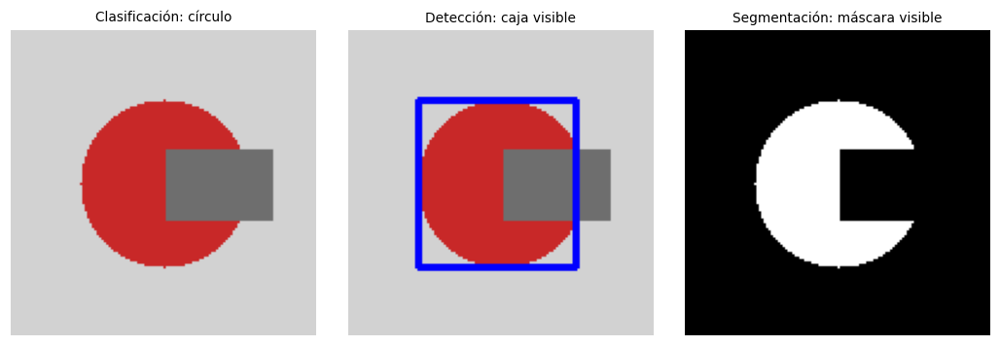

{'clase': 'circulo', 'bbox_xyxy': [29, 29, 96, 100], 'ocluido': True, 'fraccion_visible': 0.7404619776797301, 'protocolo': 'visible-v1'}


In [43]:
escena66=np.full((128,128,3),210,np.uint8)
mask66=np.zeros((128,128),np.uint8);cv2.circle(mask66,(64,64),35,1,-1)
escena66[mask66==1]=(200,40,40)
visible66=mask66.copy();visible66[50:80,65:110]=0
oclu66=escena66.copy();oclu66[50:80,65:110]=110
ys66,xs66=np.where(visible66)
caja66=[int(xs66.min()),int(ys66.min()),int(xs66.max()+1),int(ys66.max()+1)]
vista66=oclu66.copy();cv2.rectangle(vista66,tuple(caja66[:2]),tuple(np.array(caja66[2:])-1),(0,0,255),2)
mostrar([oclu66,vista66,visible66],["Clasificación: círculo", "Detección: caja visible", "Segmentación: máscara visible"],vmin=0,vmax=1)
registro66={'clase':'circulo','bbox_xyxy':caja66,'ocluido':True,'fraccion_visible':float(visible66.sum()/mask66.sum()),'protocolo':'visible-v1'}
(RAIZ/'anotacion_demo.json').write_text(json.dumps(registro66,indent=2),encoding='utf-8')
# Las máscaras categóricas se redimensionan con vecino más cercano.
mask224=cv2.resize(visible66,(224,224),interpolation=cv2.INTER_NEAREST)
assert set(np.unique(mask224)) <= {0,1}
print(registro66)

### 6.6 Procedencia, metadatos y almacenamiento (PDF 68, 70, 73-74)
El manifiesto registra IDs, origen, versión, dispositivo, fecha, partición y hash.
La estructura principal usa carpetas y CSV. Se incluye la escritura opcional
de TFRecords, el formato agrupado mencionado en las diapositivas.
Los metadatos de este ejemplo describen un generador sintético.

In [44]:
import uuid
trazabilidad67=particiones.copy()
trazabilidad67['id']=[str(uuid.uuid5(uuid.NAMESPACE_URL,'unidad-I-sintetica-v1/'+r.replace('\\','/'))) for r in trazabilidad67.ruta]
trazabilidad67['origen']='generador_sintetico_semilla_7'
trazabilidad67['version']='1.0'
trazabilidad67['dispositivo']='simulador_numpy_opencv'
trazabilidad67['fecha_simulada']='2026-01-01'
trazabilidad67['datos_personales']=False
trazabilidad67['uso_documentado']='demostracion docente sintética'
assert trazabilidad67.id.is_unique
trazabilidad67.to_csv(RAIZ/'trazabilidad.csv',index=False)
subset67=trazabilidad67.query("particion == 'train'").head(12)
if importlib.util.find_spec('tensorflow') is not None:
    import tensorflow as tf
    ruta_tf67=str(RAIZ/'train_demo.tfrecord')
    with tf.io.TFRecordWriter(ruta_tf67) as writer67:
        for fila67 in subset67.itertuples():
            campos67={k:tf.train.Feature(bytes_list=tf.train.BytesList(value=[v])) for k,v in
                      {'imagen_png':(RAIZ/fila67.ruta).read_bytes(),'clase':fila67.clase.encode(),'id':fila67.id.encode()}.items()}
            writer67.write(tf.train.Example(features=tf.train.Features(feature=campos67)).SerializeToString())
    assert sum(1 for _ in tf.data.TFRecordDataset([ruta_tf67]))==len(subset67)
else:
    print('Extensión TFRecords omitida: TensorFlow no está instalado. Se conservan las carpetas y los manifiestos CSV.')

### 6.7 Submuestreo y aumento de la clase minoritaria
El submuestreo reduce las clases con más imágenes. El sobremuestreo repite
muestras y el aumento genera variaciones de las existentes. Se aplican al
entrenamiento y se conserva la etiqueta de la clase.

,train_original,submuestreo
clase,,
circulo,235,65
cuadrado,160,65
triangulo,65,65


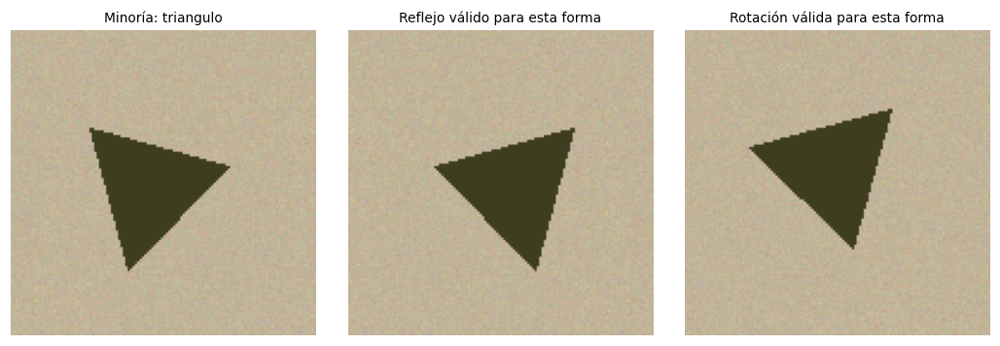

In [45]:
train68=particiones.query("particion=='train'")
n_min68=train68.clase.value_counts().min()
sub68=pd.concat([g.sample(n_min68,random_state=68) for _,g in train68.groupby('clase')])
display(pd.DataFrame({'train_original':train68.clase.value_counts(),'submuestreo':sub68.clase.value_counts()}))
minoria68=train68.clase.value_counts().idxmin()
im68=np.array(Image.open(RAIZ/train68.query('clase==@minoria68').iloc[0].ruta).convert('RGB'))
mostrar([im68,cv2.flip(im68,1),cv2.rotate(im68,cv2.ROTATE_90_CLOCKWISE)],['Minoría: '+minoria68,'Reflejo válido para esta forma','Rotación válida para esta forma'])

**Para discutir en clase**
1. ¿Por qué las tomas de un objeto deben permanecer en una sola partición?
2. ¿Qué campos permiten conocer la procedencia de una imagen?
3. ¿Qué ventajas y limitaciones tienen el submuestreo y el aumento de las clases minoritarias?

---
# Ejemplo 7 · Evaluación de calidad de datos visuales

**Objetivo.** Auditar el dataset del Ejemplo 6 después de "contaminarlo" con los problemas típicos de un proyecto real. Como sabemos exactamente qué sembramos, podemos evaluar también **al auditor**: qué detecta y qué se le escapa.

### 7.1 Sembrar problemas conocidos
Las etiquetas viven en un archivo de anotaciones (`anotaciones.csv`), como ocurre en la mayoría de herramientas de etiquetado.

In [46]:
AUD = SALIDAS / "dataset_auditoria"
(AUD / "imagenes").mkdir(parents=True, exist_ok=True)

anot = pd.DataFrame([{"archivo": Path(r.ruta).name, "etiqueta": r.clase, "objeto_id": r.objeto_id, "lugar": r.lugar}
                     for r in meta.itertuples()])
for r in meta.itertuples():
    shutil.copy(RAIZ / r.ruta, AUD / "imagenes" / Path(r.ruta).name)

rng = np.random.default_rng(123)
disponibles = list(anot.archivo)
def tomar(n):
    elegidos = list(rng.choice(disponibles, n, replace=False))
    for e in elegidos: disponibles.remove(e)
    return elegidos
leer  = lambda a: cv2.cvtColor(cv2.imread(str(AUD / "imagenes" / a)), cv2.COLOR_BGR2RGB)
escribir = lambda a, img: cv2.imwrite(str(AUD / "imagenes" / a), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
sembrado = {}

for a in tomar(2):                                   # archivos corruptos (descarga interrumpida)
    datos = (AUD / "imagenes" / a).read_bytes(); (AUD / "imagenes" / a).write_bytes(datos[:len(datos) // 3])
    sembrado[a] = "corrupto"
for i, a in enumerate(tomar(3)):                     # duplicados exactos con otro nombre
    nuevo = f"copia_{i}_{a}"; shutil.copy(AUD / "imagenes" / a, AUD / "imagenes" / nuevo)
    anot.loc[len(anot)] = {**anot[anot.archivo == a].iloc[0].to_dict(), "archivo": nuevo}
    sembrado[nuevo] = "duplicado_exacto"
for i, a in enumerate(tomar(3)):                     # casi duplicados (recomprimidos), uno con etiqueta contradictoria
    img = cv2.resize(cv2.resize(leer(a), (100, 100), interpolation=cv2.INTER_AREA), (TAM, TAM))
    nuevo = f"externo_{i}.png"; escribir(nuevo, np.clip(img * 1.03, 0, 255).astype(np.uint8))
    fila = anot[anot.archivo == a].iloc[0].to_dict()
    etiqueta = fila["etiqueta"] if i < 2 else [c for c in CLASES if c != fila["etiqueta"]][0]
    anot.loc[len(anot)] = {**fila, "archivo": nuevo, "objeto_id": fila["objeto_id"], "etiqueta": etiqueta}
    sembrado[nuevo] = "casi_duplicado"
for a in tomar(4):                                   # desenfoque (movimiento, foco)
    escribir(a, cv2.GaussianBlur(leer(a), (0, 0), 2.5)); sembrado[a] = "borrosa"
for a in tomar(3):                                   # subexposición severa
    escribir(a, (leer(a) * 0.18).astype(np.uint8)); sembrado[a] = "oscura"
for a in tomar(2):                                   # resolución insuficiente
    escribir(a, cv2.resize(leer(a), (32, 32), interpolation=cv2.INTER_AREA)); sembrado[a] = "baja_resolucion"
for a in tomar(8):                                   # errores de anotación
    actual = anot.loc[anot.archivo == a, "etiqueta"].iloc[0]
    anot.loc[anot.archivo == a, "etiqueta"] = rng.choice([c for c in CLASES if c != actual])
    sembrado[a] = "etiqueta_erronea"

anot.to_csv(AUD / "anotaciones.csv", index=False)
print(f"{len(anot)} anotaciones · problemas sembrados:", pd.Series(sembrado).value_counts().to_dict())

586 anotaciones · problemas sembrados: {'etiqueta_erronea': 8, 'borrosa': 4, 'duplicado_exacto': 3, 'oscura': 3, 'casi_duplicado': 3, 'corrupto': 2, 'baja_resolucion': 2}


### 7.2 Calidad técnica: integridad, resolución, nitidez y exposición
Se comprueba la lectura del archivo y se calculan indicadores de tamaño,
variaciones locales y brillo. Los umbrales son reglas de la demostración:
las imágenes marcadas deben revisarse según la tarea.

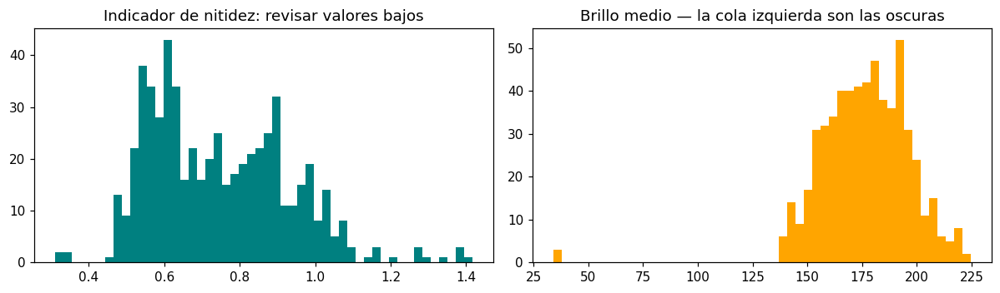

,imágenes marcadas
f_corrupto,2
f_resolucion,2
f_borrosa,0
f_exposicion,3


In [47]:
filas, huellas, miniaturas = [], {}, {}
for r in anot.itertuples():
    ruta = AUD / "imagenes" / r.archivo
    reg = {"archivo": r.archivo}
    try:
        with Image.open(ruta) as im:
            im.load(); img = np.array(im.convert("RGB"))
        reg["legible"] = True
    except Exception as e:
        reg["legible"] = False; filas.append(reg); continue
    gris = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    est = (gris - gris.mean()) / (gris.std() + 1e-6)
    reg.update({"alto": img.shape[0], "ancho": img.shape[1],
                "nitidez": float(np.mean(np.hypot(cv2.Sobel(est.astype(np.float32),cv2.CV_32F,1,0),cv2.Sobel(est.astype(np.float32),cv2.CV_32F,0,1)))),
                "brillo_medio": gris.mean(),
                "md5": hashlib.md5(ruta.read_bytes()).hexdigest()})
    huellas[r.archivo] = cv2.resize(img, (16, 16), interpolation=cv2.INTER_AREA).astype(np.float32).ravel()
    miniaturas[r.archivo] = cv2.resize(gris, (64, 64), interpolation=cv2.INTER_AREA)
    filas.append(reg)

cal = anot.merge(pd.DataFrame(filas), on="archivo")
ok = cal.legible
umbral_nitidez = 0.35 * cal.loc[ok,"nitidez"].median()

cal["f_corrupto"]    = ~cal.legible
cal["f_resolucion"]  = ok & (cal[["alto", "ancho"]].min(axis=1) < 64)
cal["f_borrosa"]     = ok & ~cal.f_resolucion & (cal.nitidez < umbral_nitidez)
cal["f_exposicion"]  = ok & ((cal.brillo_medio < 50) | (cal.brillo_medio > 235))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
axes[0].hist(cal.nitidez[ok], bins=50, color="teal"); axes[0].set_title("Indicador de nitidez: revisar valores bajos")
axes[1].hist(cal.brillo_medio[ok], bins=50, color="orange"); axes[1].set_title("Brillo medio — la cola izquierda son las oscuras")
plt.tight_layout(); plt.show()
cal[["f_corrupto", "f_resolucion", "f_borrosa", "f_exposicion"]].sum().to_frame("imágenes marcadas")

### 7.3 Duplicados exactos y posibles duplicados
Se compara el contenido de los archivos para detectar copias exactas.
Las imágenes muy parecidas se marcan mediante una comparación simple de
píxeles reducidos. Son candidatos para revisión, no duplicados confirmados.

In [48]:
legibles=cal[ok].reset_index(drop=True)
cal['f_dup_exacto']=cal.duplicated('md5',keep='first') & ok
nombres=list(legibles.archivo)
T=np.stack([huellas[a] for a in nombres])
registros_pares=[]
for i in range(len(T)-1):
    diferencia=np.abs(T[i+1:]-T[i]).mean(axis=1)
    for j in np.flatnonzero(diferencia<3)+i+1:
        if legibles.md5[i]==legibles.md5[j]: continue
        registros_pares.append({'a':nombres[i],'b':nombres[j],
                               'diferencia_media':float(diferencia[j-i-1]),
                               'etiquetas_en_conflicto':legibles.etiqueta[i]!=legibles.etiqueta[j]})
pares=pd.DataFrame(registros_pares,columns=['a','b','diferencia_media','etiquetas_en_conflicto'])
cal['f_casi_dup']=cal.archivo.isin(pares.b)
print('Copias exactas:',int(cal.f_dup_exacto.sum()),'; pares para revisar:',len(pares))
display(pares.head(15))

Copias exactas: 3 ; pares para revisar: 14


,a,b,diferencia_media,etiquetas_en_conflicto
0,circulo_obj009_toma3.png,circulo_obj009_toma4.png,2.016927,False
1,circulo_obj018_toma0.png,circulo_obj018_toma1.png,2.712240,False
2,circulo_obj019_toma0.png,circulo_obj024_toma4.png,2.333333,False
3,circulo_obj029_toma1.png,circulo_obj040_toma4.png,2.770833,False
4,circulo_obj030_toma1.png,circulo_obj030_toma3.png,2.391927,False
5,circulo_obj039_toma3.png,circulo_obj039_toma4.png,2.466146,False
6,circulo_obj040_toma3.png,circulo_obj040_toma4.png,2.708333,False
7,circulo_obj045_toma3.png,circulo_obj045_toma4.png,2.912760,False
8,circulo_obj050_toma1.png,circulo_obj050_toma2.png,1.720052,False
9,circulo_obj051_toma1.png,circulo_obj051_toma3.png,2.279948,False


### 7.4 Sesgo de captura y correlaciones espurias
Comparamos la distribución de clases por lugar de captura. Si una clase aparece
principalmente en un lugar, el fondo puede convertirse en un atajo para el modelo.
La prueba con Grad-CAM y cambio de fondo se realiza más adelante.

etiqueta,circulo,cuadrado,triangulo
lugar,,,
lab_A,254,34,20
lab_B,49,166,61


etiqueta,circulo,cuadrado,triangulo
lugar,,,
lab_A,0.838,0.17,0.247
lab_B,0.162,0.83,0.753


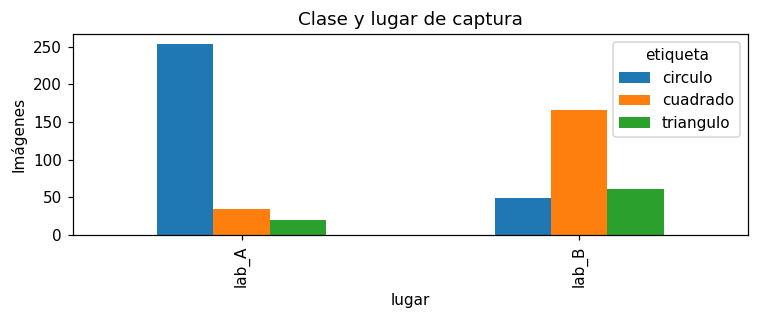

In [49]:
tabla=pd.crosstab(legibles.lugar,legibles.etiqueta)
display(tabla)
display(pd.crosstab(legibles.lugar,legibles.etiqueta,normalize='columns').round(3))
tabla.plot.bar(figsize=(7,3),title='Clase y lugar de captura');plt.ylabel('Imágenes');plt.tight_layout();plt.show()
def color_fondo(img):
    borde=np.concatenate([img[0],img[-1],img[:,0],img[:,-1]])
    return np.median(borde,axis=0)
imgs={a:np.array(Image.open(AUD/'imagenes'/a).convert('RGB')) for a in legibles.archivo}

### 7.5 Inconsistencias de etiquetado
En este dataset sintético conocemos la clase de cada objeto antes de introducir
errores. Esa referencia permite simular una revisión de anotaciones.
En datos reales, los desacuerdos requieren una guía de etiquetado y revisión humana.

,archivo,etiqueta,etiqueta_referencia
84,circulo_obj017_toma0.png,triangulo,circulo
134,circulo_obj027_toma0.png,cuadrado,circulo
235,circulo_obj047_toma1.png,cuadrado,circulo
253,circulo_obj050_toma4.png,cuadrado,circulo
362,cuadrado_obj012_toma3.png,circulo,cuadrado
422,cuadrado_obj024_toma4.png,circulo,cuadrado
425,cuadrado_obj025_toma2.png,circulo,cuadrado
535,triangulo_obj007_toma2.png,circulo,triangulo
583,externo_2.png,cuadrado,circulo


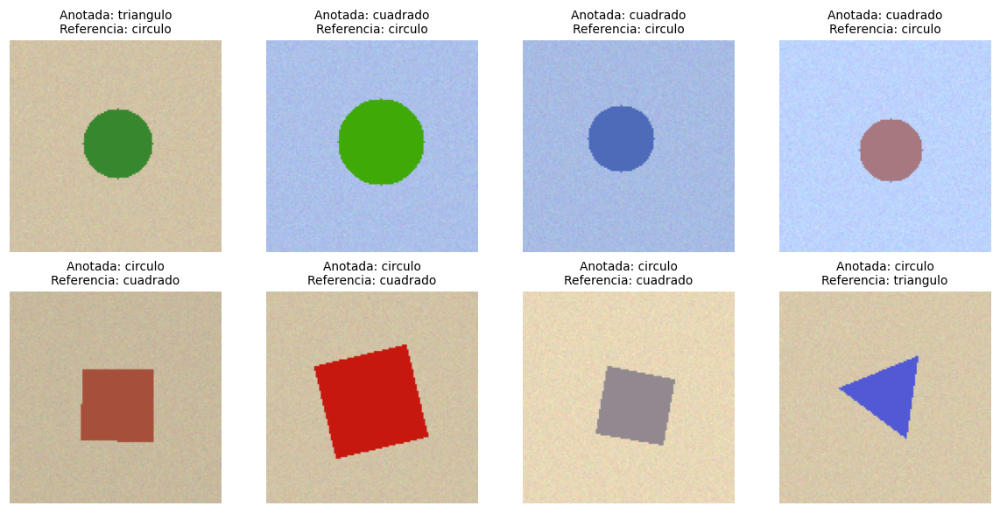

In [50]:
referencia75=meta.drop_duplicates('objeto_id').set_index('objeto_id').clase
legibles['etiqueta_referencia']=legibles.objeto_id.map(referencia75)
sospechosas=legibles[legibles.etiqueta!=legibles.etiqueta_referencia]
cal['f_etiqueta']=cal.archivo.isin(sospechosas.archivo)
display(sospechosas[['archivo','etiqueta','etiqueta_referencia']])
mostrar([imgs[a] for a in sospechosas.archivo[:8]],
        [f"Anotada: {a}\nReferencia: {b}" for a,b in zip(sospechosas.etiqueta[:8],sospechosas.etiqueta_referencia[:8])],cols=4,tam=2.7)

### 7.6 Desbalance, F1 y matriz de confusión
Se usan **predicciones simuladas** para ilustrar cómo leer las métricas de las
diapositivas. No son resultados de un modelo entrenado. Comparamos predecir
siempre la clase mayoritaria con un conjunto de predicciones que comete errores
en las tres clases.

,Exactitud,F1 macro,F1 micro
Siempre mayoritaria,0.521,0.228,0.521
Predicciones simuladas,0.800,0.772,0.800


              precision    recall  f1-score   support

     circulo       0.88      0.81      0.84       304
    cuadrado       0.82      0.78      0.80       199
   triangulo       0.57      0.81      0.67        81

    accuracy                           0.80       584
   macro avg       0.76      0.80      0.77       584
weighted avg       0.82      0.80      0.80       584



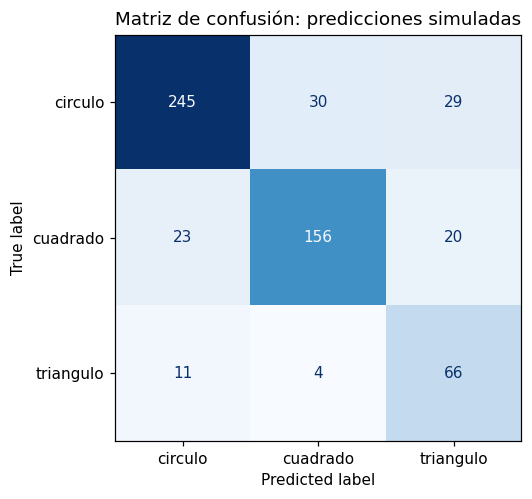

In [51]:
from sklearn.metrics import accuracy_score,f1_score,ConfusionMatrixDisplay,classification_report
yl=legibles.etiqueta_referencia.to_numpy()
pred_mayoria=np.full(len(yl),pd.Series(yl).value_counts().idxmax(),dtype=object)
pred_demo=yl.copy();rng76=np.random.default_rng(76)
equivocados76=rng76.choice(len(yl),size=round(.2*len(yl)),replace=False)
for i in equivocados76: pred_demo[i]=rng76.choice([cl for cl in CLASES if cl!=yl[i]])
display(pd.DataFrame({nombre:{'Exactitud':accuracy_score(yl,pred),
                              'F1 macro':f1_score(yl,pred,average='macro'),
                              'F1 micro':f1_score(yl,pred,average='micro')}
                      for nombre,pred in [('Siempre mayoritaria',pred_mayoria),('Predicciones simuladas',pred_demo)]}).T.round(3))
print(classification_report(yl,pred_demo,zero_division=0))
ConfusionMatrixDisplay.from_predictions(yl,pred_demo,labels=CLASES,cmap='Blues',colorbar=False)
plt.title('Matriz de confusión: predicciones simuladas');plt.show()

### 7.7 Informe de auditoría: decisión por imagen y evaluación del auditor

In [52]:
reglas = [("f_corrupto", "DESCARTAR", "archivo ilegible"),
          ("f_dup_exacto", "DESCARTAR", "duplicado exacto"),
          ("f_casi_dup", "REVISAR", "casi duplicado de otra imagen"),
          ("f_resolucion", "DESCARTAR", "resolución < 64 px"),
          ("f_exposicion", "CORREGIR", "exposición fuera de rango (brillo/CLAHE)"),
          ("f_borrosa", "REVISAR", "nitidez anómala"),
          ("f_etiqueta", "REVISAR", "etiqueta sospechosa")]
def decidir(fila):
    for col, accion, motivo in reglas:
        if bool(fila.get(col, False)): return pd.Series({"accion": accion, "motivo": motivo})
    return pd.Series({"accion": "CONSERVAR", "motivo": ""})

cal = cal.fillna({c: False for c, _, _ in reglas})
informe = pd.concat([cal[["archivo", "etiqueta"]], cal.apply(decidir, axis=1)], axis=1)
informe.to_csv(AUD / "informe_auditoria.csv", index=False)
display(informe.accion.value_counts().to_frame("imágenes"))

# ¿Qué tan bueno fue el auditor? Comparamos con lo que sembramos
esperado = {"corrupto": "f_corrupto", "duplicado_exacto": "f_dup_exacto", "casi_duplicado": "f_casi_dup",
            "borrosa": "f_borrosa", "oscura": "f_exposicion", "baja_resolucion": "f_resolucion", "etiqueta_erronea": "f_etiqueta"}
evaluacion = []
for problema, col in esperado.items():
    sembrados = [a for a, p in sembrado.items() if p == problema]
    marcados = set(cal.archivo[cal[col]])
    evaluacion.append({"problema": problema, "sembrados": len(sembrados),
                       "detectados": sum(a in marcados for a in sembrados),
                       "marcadas sin ningún problema sembrado": len(marcados - set(sembrado))})
display(pd.DataFrame(evaluacion).set_index("problema"))

,imágenes
accion,
CONSERVAR,554
REVISAR,22
DESCARTAR,7
CORREGIR,3


,sembrados,detectados,marcadas sin ningún problema sembrado
problema,,,
corrupto,2,2,0
duplicado_exacto,3,3,0
casi_duplicado,3,0,13
borrosa,4,0,0
oscura,3,3,0
baja_resolucion,2,2,0
etiqueta_erronea,8,8,0


### 7.8 *Checklist* final antes de entrenar

In [53]:
def evaluar_checklist(sub):
    """sub: subconjunto de `cal` a evaluar."""
    leg = sub[sub.legible]
    conteo = leg.etiqueta.value_counts().reindex(CLASES, fill_value=0)
    conflicto = len(pares) > 0 and bool((pares.etiquetas_en_conflicto & pares.a.isin(sub.archivo) & pares.b.isin(sub.archivo)).any())
    return {
        "Todos los archivos son legibles":                  not sub.f_corrupto.any(),
        "Sin duplicados exactos":                           not sub.duplicated("md5").any(),
        "Sin casi duplicados con etiquetas en conflicto":   not conflicto,
        "Resolución mínima garantizada":                    not sub.f_resolucion.any(),
        "Exposición y nitidez dentro de rango":             not (sub.f_exposicion.any() or sub.f_borrosa.any()),
        "Sin etiquetas sospechosas pendientes":             not sub.f_etiqueta.any(),
        "Desbalance máx/mín ≤ 3":                           conteo.min() > 0 and conteo.max() / conteo.min() <= 3,
        "Particiones sin objetos compartidos (Ejemplo 6)":  objetos_filtrados(por_grupos) == 0,
    }

limpio = (informe.accion == "CONSERVAR").values
antes, despues = evaluar_checklist(cal), evaluar_checklist(cal[limpio])
marca = lambda v: "✅" if v else "⚠️"
display(pd.DataFrame({"Dataset recibido": {k: marca(v) for k, v in antes.items()},
                      "Tras aplicar el informe": {k: marca(v) for k, v in despues.items()}}))
print(f"Imágenes conservables sin intervención: {limpio.sum()} de {len(informe)}")
print("Filtrar resuelve los defectos técnicos; el desbalance y el sesgo de fondo exigen acciones sobre la recolección.")

,Dataset recibido,Tras aplicar el informe
Todos los archivos son legibles,⚠️,✅
Sin duplicados exactos,⚠️,✅
Sin casi duplicados con etiquetas en conflicto,✅,✅
Resolución mínima garantizada,⚠️,✅
Exposición y nitidez dentro de rango,⚠️,✅
Sin etiquetas sospechosas pendientes,⚠️,✅
Desbalance máx/mín ≤ 3,⚠️,⚠️
Particiones sin objetos compartidos (Ejemplo 6),✅,✅


Imágenes conservables sin intervención: 554 de 586
Filtrar resuelve los defectos técnicos; el desbalance y el sesgo de fondo exigen acciones sobre la recolección.


### 7.9 Anotación, revisión y representatividad (PDF 71-72, 81, 84)
Comparamos cajas con IoU, máscaras y etiquetas entre dos anotadores simulados.
Los desacuerdos se derivan a revisión. Para ilustrar la priorización de muestras
inciertas del PDF, se usan puntuaciones de confianza simuladas: menor confianza
implica mayor prioridad, sin modificar etiquetas automáticamente.

In [54]:
def iou_cajas(a,b):
    izq=np.maximum(a[:2],b[:2]);der=np.minimum(a[2:],b[2:])
    inter=np.prod(np.maximum(der-izq,0))
    area_a=np.prod(np.maximum(np.array(a[2:])-a[:2],0));area_b=np.prod(np.maximum(np.array(b[2:])-b[:2],0))
    return float(inter/(area_a+area_b-inter)) if area_a+area_b>inter else 1.0
caja_b79=(np.array(caja66)+[5,0,5,0]).tolist()
mask_b79=np.roll(visible66,5,axis=1).astype(bool);mask_a79=visible66.astype(bool)
print('IoU cajas:',round(iou_cajas(caja66,caja_b79),3))
print('IoU máscaras:',round(np.logical_and(mask_a79,mask_b79).sum()/np.logical_or(mask_a79,mask_b79).sum(),3))
anot_a79=np.array(['circulo','cuadrado','triangulo']*10)
anot_b79=anot_a79.copy();anot_b79[[2,7,12]]='circulo'
print('Acuerdo de etiquetas:',float((anot_a79==anot_b79).mean()))
print('Desacuerdos para revisión:',np.flatnonzero(anot_a79!=anot_b79).tolist())
confianza79=np.random.default_rng(79).uniform(.35,.99,len(legibles))
cola79=legibles[['archivo','etiqueta']].assign(confianza_simulada=confianza79).sort_values('confianza_simulada').head(10)
display(cola79)
cola79.to_csv(AUD/'cola_revision_humana.csv',index=False)
display(pd.crosstab(particiones.lugar,[particiones.particion,particiones.clase]))
print('Cobertura de dispositivos: solo un simulador. Demografía: no aplica a figuras; no demuestra representatividad de personas.')

IoU cajas: 0.861
IoU máscaras: 0.783
Acuerdo de etiquetas: 0.9333333333333333
Desacuerdos para revisión: [2, 7]


,archivo,etiqueta,confianza_simulada
38,circulo_obj007_toma4.png,circulo,0.351634
100,circulo_obj020_toma1.png,circulo,0.353085
367,cuadrado_obj013_toma3.png,cuadrado,0.353644
83,circulo_obj016_toma4.png,circulo,0.353695
120,circulo_obj024_toma1.png,circulo,0.354001
439,cuadrado_obj028_toma1.png,cuadrado,0.354027
257,circulo_obj051_toma3.png,circulo,0.354320
533,triangulo_obj007_toma0.png,triangulo,0.354488
536,triangulo_obj007_toma3.png,triangulo,0.354624
514,triangulo_obj003_toma1.png,triangulo,0.355297


particion    test                      train                        val                   
clase     circulo cuadrado triangulo circulo cuadrado triangulo circulo cuadrado triangulo
lugar                                                                                     
lab_A          30        0         0     195       30        15      30        0         5
lab_B           5       20         5      40      130        50       0       20         5

Cobertura de dispositivos: solo un simulador. Demografía: no aplica a figuras; no demuestra representatividad de personas.


### 7.10 Grad-CAM y prueba contrafactual del fondo (PDF 85)
Entrenamos una CNN pequeña **solo con train**. Grad-CAM pondera mapas de activación
por el gradiente de una clase. Cambiar el fondo preservando el objeto permite
comprobar sensibilidad al contexto. Un mapa de calor no prueba causalidad ni
calidad del modelo; se combina con pruebas y métricas. Se inspecciona validación,
sin utilizar test para escoger el modelo.

,circulo,cuadrado,triangulo
Fondo original,0.759830,0.176066,0.064104
Fondo cambiado,0.450092,0.339964,0.209944


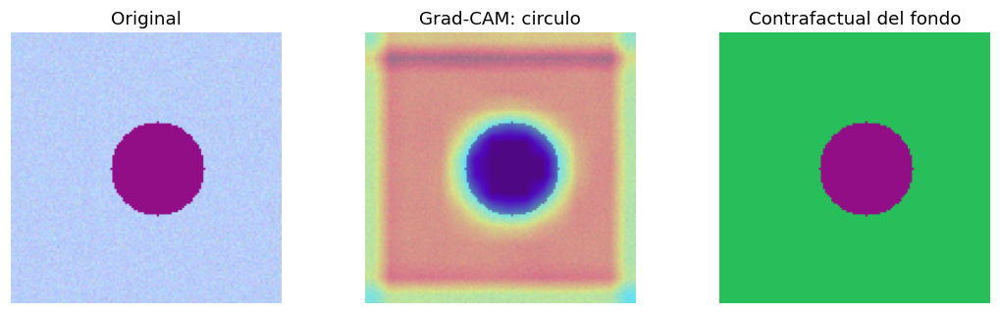

Clase real: circulo ; variación máxima de probabilidad: 0.30973750352859497


In [55]:
torch.manual_seed(710)
torch.set_num_threads(min(4,torch.get_num_threads()))
class CNN710(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.features=torch.nn.Sequential(torch.nn.Conv2d(3,8,3,padding=1),torch.nn.ReLU(),torch.nn.MaxPool2d(2),
                                           torch.nn.Conv2d(8,16,3,padding=1),torch.nn.ReLU())
        self.classifier=torch.nn.Linear(16,3)
    def forward(self,x):
        a=self.features(x)
        return self.classifier(a.mean((2,3)))
def tensor710(im):
    return torch.from_numpy(cv2.resize(im,(32,32)).copy()).permute(2,0,1).float()/255
train710=particiones.query("particion=='train'")
x710=torch.stack([tensor710(np.array(Image.open(RAIZ/r).convert('RGB'))) for r in train710.ruta])
y710=torch.tensor([CLASES.index(cl) for cl in train710.clase])
cnn710=CNN710();optim710=torch.optim.Adam(cnn710.parameters(),lr=.01)
cnn710.train()
for ep710 in range(8):
    for ids710 in torch.randperm(len(x710)).split(64):
        optim710.zero_grad();loss710=torch.nn.functional.cross_entropy(cnn710(x710[ids710]),y710[ids710]);loss710.backward();optim710.step()
cnn710.eval()
fila710=particiones.query("particion=='val'").iloc[0]
im710=np.array(Image.open(RAIZ/fila710.ruta).convert('RGB'))
fondo710=color_fondo(im710)
dist710=np.linalg.norm(im710.astype(float)-fondo710,axis=2).astype(np.float32)
_,mas710=cv2.threshold(cv2.normalize(dist710,None,0,255,cv2.NORM_MINMAX).astype(np.uint8),0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
cf710=im710.copy();cf710[mas710==0]=(40,190,90)
with torch.no_grad():
    prob710=torch.softmax(cnn710(torch.stack([tensor710(im710),tensor710(cf710)])),1).numpy()
display(pd.DataFrame(prob710,index=['Fondo original','Fondo cambiado'],columns=CLASES))
input710=tensor710(im710).unsqueeze(0)
act710=cnn710.features(input710);act710.retain_grad()
score710=cnn710.classifier(act710.mean((2,3)))
cl710=int(score710.argmax(1));cnn710.zero_grad();score710[0,cl710].backward()
pesos710=act710.grad.mean((2,3),keepdim=True)
cam710=torch.relu((pesos710*act710).sum(1))[0].detach().numpy()
cam710=cv2.resize(cam710,(TAM,TAM));cam710/=max(float(cam710.max()),1e-8)
fig,ax=plt.subplots(1,3,figsize=(10,3))
for a710,imagen710,titulo710 in zip(ax,[im710,im710,cf710],['Original','Grad-CAM: '+CLASES[cl710],'Contrafactual del fondo']):
    a710.imshow(imagen710);a710.set_title(titulo710);a710.axis('off')
ax[1].imshow(cam710,cmap='jet',alpha=.45,vmin=0,vmax=1);plt.tight_layout();plt.show()
print('Clase real:',fila710.clase,'; variación máxima de probabilidad:',float(np.abs(prob710[0]-prob710[1]).max()))

### 7.11 Privacidad: píxeles y metadatos (PDF 86)
Usamos identificadores ficticios. Cubrimos la región conocida y exportamos
los píxeles sin EXIF. En una aplicación real también deben revisarse los campos
DICOM y cualquier texto incrustado; cubrir una región no garantiza anonimización completa.

La diapositiva también menciona privacidad diferencial como protección mediante
ruido controlado. Se mantiene como concepto: esta demostración de ocultación
de píxeles no implementa privacidad diferencial.

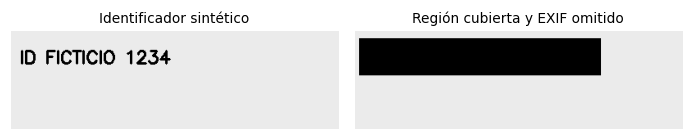

In [56]:
priv711=np.full((120,400,3),235,np.uint8)
cv2.putText(priv711,'ID FICTICIO 1234',(10,40),cv2.FONT_HERSHEY_SIMPLEX,.7,(0,0,0),2)
protegida711=priv711.copy();protegida711[10:55,5:300]=0
ruta711=SALIDAS/'sin_metadatos.png'
Image.fromarray(protegida711).save(ruta711)
with Image.open(ruta711) as im711:
    assert not im711.getexif()
mostrar([priv711,protegida711],['Identificador sintético','Región cubierta y EXIF omitido'])

### 7.12 Checklist ampliado y ficha del dataset (PDF 87)
Una condición no verificada debe quedar pendiente. Para estas figuras no se
evalúa diversidad demográfica; el entorno simulado tampoco permite asegurar
representatividad en producción. Los defectos detectados no se corrigen
automáticamente ni se confunden con una certificación legal.

In [57]:
ficha712={'nombre':'Figuras sintéticas Unidad I','version':'1.0','origen':'generador local, semilla 7',
          'tareas':['clasificación; detección y segmentación en demo 6.5'],
          'uso':'docencia','datos_personales':'no: figuras sintéticas',
          'limitaciones':['sesgo de fondo deliberado','un simulador','sin validación en capturas reales'],
          'licencias_fuentes_externas':'no aplica al dataset de figuras; revisar cada fuente si se incorporan imágenes externas',
          'guia_anotacion':'visible-v1','splits':'splits.csv; separados por objeto',
          'revision_humana':'pendiente para muestras marcadas por el auditor'}
(AUD/'ficha_dataset.json').write_text(json.dumps(ficha712,ensure_ascii=False,indent=2),encoding='utf-8')
checks712={'IDs únicos':bool(trazabilidad67.id.is_unique),
           'Procedencia documentada':bool(trazabilidad67.origen.notna().all()),
           'Grupos separados':objetos_filtrados(por_grupos)==0,
           'Metadatos de demo privada retirados':not bool(Image.open(ruta711).getexif()),
           'Anotaciones sospechosas resueltas':not bool(cal.f_etiqueta.any()),
           'Captura representativa de producción':'PENDIENTE: requiere datos reales',
           'Permisos de nuevas fuentes':'PENDIENTE si se incorporan fuentes externas'}
display(pd.Series(checks712,name='Checklist ampliado'))
print('Resultados guardados en:',SALIDAS.resolve())

,Checklist ampliado
IDs únicos,True
Procedencia documentada,True
Grupos separados,True
Metadatos de demo privada retirados,True
Anotaciones sospechosas resueltas,False
Captura representativa de producción,PENDIENTE: requiere datos reales
Permisos de nuevas fuentes,PENDIENTE si se incorporan fuentes externas


Resultados guardados en: /content/unidad_I_5b9nsmn7


**Para discutir en clase**
1. ¿Qué problemas sembrados detectó el auditor con facilidad y cuáles le costaron? ¿Por qué?
2. El *checklist* marca el sesgo de fondo. ¿Qué harían: recolectar más datos, recortar el fondo, aleatorizar el fondo con *augmentation* o documentarlo y aceptarlo?
3. ¿Qué decisiones del informe deben quedar en manos de una persona y cuáles pueden automatizarse con seguridad?